# **NLP Project - Biomedical Information Retrieval**

**Phase 1: Data Parsing · Indexing · Retrieval · Hyperparameter Tuning · Evaluation**

---

## Index

- [**1. Infrastructure**](#1-infrastructure)
  - [1.1. Setup & Environment](#11-setup--environment)
  - [1.2. Constants & Configs](#12-constants-configs)
  - [1.3. Data Loading, Splits, Qrels](#13-data-loading-splits-qrels)
    - [1.3.1. Data Loading](#131-data-loading)
    - [1.3.2. Splits & Qrels Construction](#132-splits--qrels-construction)
  - [1.4. Index & Embeddings Creation](#14--index--embeddings-creation)
- [**2. Retrieval Baselines**](#2-retrieval-baselines)
  - [2.1. BM25](#21-bm25)
  - [2.2. LM Jelinek-Mercer Retrieval Demo](#22--lm-jelinek-mercer-retrieval-demo)
  - [2.3. LM Dirichlet Retrieval Demo](#23-lm-dirichlet-retrieval-demo)
  - [2.4. Dense KNN Retrieval Demo](#24-dense-knn-retrieval-demo)
  - [2.5. RRF Fusion Retrieval Demo](#25-rrf-fusion-retrieval-demo)
- [**3. Hyperparameter Tuning**](#3-hyperparameter-tuning)
  - [3.0. Build Full Index for Grid Search](#30-build-full-index-with-all-fields-needed-for-th-grid-search)
  - [3.1. Understanding the Evaluation Metrics](#31-understanding-the-evaluation-metrics)
  - [3.2. Query Field Ablation](#32-query-field-ablation--which-part-of-the-topic-to-use-as-query)
  - [3.3. BM25 k1, b Parameter Tuning](#33-bm25---k1-b-parameter-tuning)
  - [3.4. LM-JM Lambda Selection](#34-lm-jm-lambda-selection)
  - [3.5. LM-Dirichlet μ Tuning](#35-lm-dirichlet-μ-tuning)
  - [3.6. Dense Encoder Comparison](#36-dense-encoder-comparison)
    - [3.6.1. Pooling Mode Comparison: CLS vs Mean vs Mean-No-Special](#361--pooling-mode-comparison-cls-vs-mean-vs-mean-no-special)
    - [3.6.2. Dense Encoder Comparison (5-fold CV)](#362-dense-encoder-comparison)
  - [3.7. Tuning Summary & Locked Configuration](#37--tuning-summary--locked-configuration)
  - [3.8. RRF Pair Grid Search](#38--rrf-pair-grid-search)
- [**4. Final Evaluation on Test Set**](#4--final-evaluation-on-test-set)
  - [4.1. Run File Generation on Test Set](#41--run-file-generation-on-test-set)
  - [4.2. Baseline vs Tuned on Test Set](#42--baseline-vs-tuned-on-test-set)
  - [4.3. Individual Per-Query Precision-Recall Curves](#43--individual-per-query-precision-recall-curves)
  - [4.4. Precision-Recall Curves and AP Distribution](#44--precision-recall-curves-and-ap-distribution)
- [**5. Phase 1 Summary & Locked Configuration for Phase 2**](#5--phase-1-summary--locked-configuration-for-phase-2)

---

**About the Code:**

> All logic lives in `src/`. This notebook calls the src python files, reusable, across tasks.

**AI Assistance Disclosure**

> AI tools (Claude, GitHub Copilot) were used for debugging, testing, and formatting.
> All core concepts, architecture decisions, and methodology were conceived by the authors.


# **1. Infrastructure**

---
## 1.1. Setup & Environment

Same notebook works local or in colab:

**Local setup:**
- Copy `.env.example` → `.env` and fill in your credentials
- `.env` is gitignored — never commit credentials

**Colab setup (one-time):**
1. Open Secrets panel (key icon in left sidebar)
2. Add: `OPENSEARCH_USER`, `OPENSEARCH_PASS`, `OPENSEARCH_INDEX`
3. Toggle "Notebook access" ON for each
4. Run this cell — it reads them as env vars, identical to `.env` locally

In [ ]:
import sys
import os
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # -- clone / update the repo --
    if not os.path.exists("/content/nlp-biomedical-agent"):
        os.system("git clone https://github.com/fmssilva/NLP_BioMedical_Agent.git /content/nlp-biomedical-agent")
    else:
        os.system("git -C /content/nlp-biomedical-agent pull --ff-only")
    os.chdir("/content/nlp-biomedical-agent")
    os.system("pip install -r requirements.txt -q")

    # -- credentials via Colab Secrets (Secrets panel in the left sidebar) --
    from google.colab import userdata
    for _key in ["OPENSEARCH_HOST", "OPENSEARCH_PORT", "OPENSEARCH_USER", "OPENSEARCH_PASS", "OPENSEARCH_INDEX"]:
        try:
            os.environ[_key] = userdata.get(_key)
        except userdata.SecretNotFoundError:
            pass

    _missing = [k for k in ["OPENSEARCH_USER", "OPENSEARCH_PASS", "OPENSEARCH_INDEX"] if not os.getenv(k)]
    if _missing:
        raise EnvironmentError(
            f"Missing Colab Secrets: {_missing}\n"
            "Colab sidebar > Secrets > add and enable them, then re-run this cell."
        )

else:
    # -- local: .env file at project root (never committed to git, see .gitignore) --
    from dotenv import load_dotenv
    _cwd = Path(os.getcwd()).resolve()
    for _parent in [_cwd, _cwd.parent, _cwd.parent.parent]:
        _env = _parent / ".env"
        if _env.exists():
            load_dotenv(_env)
            break

    # enable autoreload so edits to src/ reflect immediately without re-running the kernel
    from IPython import get_ipython
    _ipy = get_ipython()
    if _ipy:
        _ipy.run_line_magic("load_ext", "autoreload")
        _ipy.run_line_magic("autoreload", "2")

# resolve project root (works for both local and Colab)
# NOTE: the notebook lives in tasks/
ROOT = Path(os.getcwd()).resolve()
for _p in [ROOT, ROOT.parent]:
    if (_p / "requirements.txt").exists():
        ROOT = _p
        break

# Add project root to sys.path AFTER ROOT correction
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Purge any stale 'src' module cached from a different project (shared kernel)
_our_src = str(ROOT / "src")
if "src" in sys.modules and _our_src not in getattr(sys.modules["src"], "__path__", []):
    _stale = [k for k in sys.modules if k == "src" or k.startswith("src.")]
    for k in _stale:
        del sys.modules[k]

# -- connect to OpenSearch and verify the index is ready --
from src.indexing.opensearch_client import get_client, check_index

client     = get_client()
index_name = os.getenv("OPENSEARCH_INDEX", "")
assert index_name, "OPENSEARCH_INDEX not set — check .env (local) or Colab Secrets (Colab)"

print(f"Project root : {ROOT}")
print(f"In Colab     : {IN_COLAB}")
print(f"Index name   : {index_name}")

check_index(client, index_name)   # prints doc count and field info; no-op if index not yet created

Project root : /content/nlp-biomedical-agent
In Colab     : True
Index name   : usernlp03
[index] 'usernlp03'  docs=4194  [ok] fully populated


True

---
## 1.2. CONSTANTS CONFIGs

Constants are grouped:
- **Flags** — toggle heavy operations (re-index, re-encode) without deleting cached files
- **Data paths** — where raw data, results, and embeddings live
- **Retrieval search size** — how many docs each retriever returns per query
- **Qrels settings** — relevance scoring thresholds
- **Index settings** — shards, replicas, HNSW parameters baked into the index at creation time
- **Encoder** — which sentence encoder to use for the initial KNN field
- **Tuning grids** — parameter ranges explored during hyperparameter sweeps
- **Best (locked) parameters** — winners from 5-fold CV on 32 train queries; used in final eval


In [2]:

CORPUS_SIZE = None  # small int for testing; None for the full corpus

# ── Flags ────────────────────────────────────────────────────────────────────
# These are heavy operations. Set to true only if you want to force a refresh
FORCE_REINDEX  = False   # True -> delete + recreate the OpenSearch index and re-bulk-index all docs
FORCE_REENCODE = False   # True -> re-encode corpus with ENCODER_MODEL even if .npy already exists

# ── Retrieval size ───────────────────────────────────────────────────────────
RETRIEVAL_SIZE = 100   # number of docs retriever returns per query

# ── Qrels relevance settings ─────────────────────────────────────────────────
GRADED_SCORE = {
    "supporting":       5,   # strong evidence
    "neutral":          2,   # mentioned but not clearly supporting
    "not relevant":     0,
    "contradicting":    0,
    "invalid citation": 0,
}
BINARY_THRESHOLD = 5         # score >= this -> counted as relevant in binary qrels
                             # Change to 1 if wanting to include "neutral" also as valid binary docs

# ── Index creation settings ───────────────────────────────────────────────────
INDEX_N_SHARDS      = 4      # parallel shards for bulk indexing speed
INDEX_N_REPLICAS    = 0      # 0 for single-node dev; set 1+ for production HA
INDEX_REFRESH_INT   = "-1"   # disable auto-refresh during bulk indexing (faster)
INDEX_EF_SEARCH     = 100    # HNSW ef_search — controls how many candidate neighbors are explored during KNN search
INDEX_EF_CONSTRUCT  = 256    # HNSW ef_construction — controls search breadth when building the graph
INDEX_HNSW_M        = 48     # HNSW M — number of bi-directional links (neighbors) per node in the graph
INDEX_EMBEDDING_DIM = 768    # Dimensionality of the vectors stored in the KNN field
ENCODE_BATCH_SIZE   = 32     # documents per encoding batch


# ── Encoder model tuples: (short_name, hf_model_id, embedding_dim) ──────────
ENCODER_MS_MARCO  = ("msmarco",  "sentence-transformers/msmarco-distilbert-base-v2",    768)
ENCODER_MED_CPT   = ("medcpt",   "ncbi/MedCPT-Query-Encoder",                           768)
# MedCPT is asymmetric: the tuple above is the Query-Encoder used at *query time* by KNNRetriever.
# At *corpus encoding time*, corpus_encoder.create_embeddings() automatically detects the "medcpt"
# alias and uses ncbi/MedCPT-Article-Encoder with CLS pooling (max_length=512) instead.
# Both encoders share the same 768-dim vector space by design, so no index change is needed.
ENCODER_MULTI_QA  = ("multi-qa", "sentence-transformers/multi-qa-mpnet-base-cos-v1",    768)
ENCODER_SPECTER2  = ("specter2", "allenai/specter2_base",                                768)

# ── Active list for knn models ────────────────────────────────────────────────
ENCODERS_LIST = [
    ENCODER_MS_MARCO,
    ENCODER_MED_CPT,
    ENCODER_MULTI_QA,
    ENCODER_SPECTER2,
]


# ── DEFAULT — Baseline similarity fields ─────────────────────────────────────
BM25_K1_B_DEFAULT    = [(1.2, 0.75)]
LMJM_LAMBDAS_DEFAULT = [0.7]
LMDIR_MU_DEFAULT     = [2000]
ENCODER_MODEL_DEFAULT = ENCODER_MS_MARCO

# ── TUNING GRID VALUES ───────────────────────────────────────────────────────
N_CV_FOLDS        = 5
BM25_K1_GRID      = [0.5, 0.8, 1.0, 1.2, 1.5, 1.7]
BM25_B_GRID       = [0.25, 0.5, 0.75, 1.0]
BM25_K1_B_GRID    = [(k1, b) for k1 in BM25_K1_GRID for b in BM25_B_GRID]
LMJM_LAMBDAS_GRID = [0.1, 0.3, 0.5, 0.65, 0.7, 0.75, 0.9]
LMDIR_MU_GRID     = [50, 75, 90, 100, 125, 200, 500, 1000, 2000]

# ── BEST / LOCKED PARAMS ——————————————————————————————————————————————————————
# We set here the best estimates and then we need to confirm the correct values to pass on to phase 2 after running the notebok.
BEST_QUERY_FIELD  = "topic+question"
BM25_K1_B_BEST    = (1.5, 1.0)
LMJM_LAMBDA_BEST  = 0.65
LMDIR_MU_BEST     = 100
ENCODER_BEST      = ENCODER_MED_CPT
RRF_K             = 60
RRF_BEST_K        = 60
RRF_BEST_PAIR     = "BM25 + KNN(MedCPT)"
BEST_OVERALL_STRAT = "KNN(MedCPT)"
BEST_OVERALL_KEY   = "knn_best"


############## PATHS #########################

# ── Data files Paths ─────────────────────────────────────────────────────────
DRIVE_FOLDER = "https://drive.google.com/drive/folders/1E-KfGiX9YTC3q2WNbtJ5MJYL7tcruANp?usp=sharing"

CORPUS_FILE        = "data/filtered_pubmed_abstracts.txt"
TOPICS_FILE        = "data/BioGen2024topics.json"
SUBMISSIONS_FILE   = "data/biogen_2024_submissions.json"
QRELS_BINARY_FILE  = "results/qrels/qrels.json"
QRELS_GRADED_FILE  = "results/qrels/qrels_graded.json"

# ── Results / output directories ─────────────────────────────────────────────
SPLITS_DIR         = ROOT / "results/splits"
EMBEDDINGS_DIR     = ROOT / "results/embeddings"
TUNING_DIR         = ROOT / "results/phase1/tuning"
PHASE1_RESULTS_DIR = ROOT / "results/phase1"

print("CONFIG SET UP DONE")
print(f"  CORPUS_SIZE       : {CORPUS_SIZE}  (None = full 4194 docs)")
print(f"  ENCODERS_LIST     : {[e[0] for e in ENCODERS_LIST]}")
print(f"  BM25_K1_B_BEST    : {BM25_K1_B_BEST}")
print(f"  LMJM_LAMBDA_BEST  : {LMJM_LAMBDA_BEST}")
print(f"  LMDIR_MU_BEST     : {LMDIR_MU_BEST}")
print(f"  ENCODER_BEST      : {ENCODER_BEST[0]}")
print(f"  RRF_BEST_PAIR     : '{RRF_BEST_PAIR}'  k={RRF_BEST_K}")
print(f"  BEST_OVERALL_KEY  : '{BEST_OVERALL_KEY}'")


CONFIG SET UP DONE
  CORPUS_SIZE       : None  (None = full 4194 docs)
  ENCODERS_LIST     : ['msmarco', 'medcpt', 'multi-qa', 'specter2']
  BM25_K1_B_BEST    : (1.5, 1.0)
  LMJM_LAMBDA_BEST  : 0.65
  LMDIR_MU_BEST     : 100
  ENCODER_BEST      : medcpt
  RRF_BEST_PAIR     : 'BM25 + KNN(MedCPT)'  k=60
  BEST_OVERALL_KEY  : 'knn_best'


---
## 1.3. Data Loading, Splits, Qrels

**Summary of the data we have and how we process Qrels for evaluation:**

**Corpus:**  
> 4194 PubMed abstracts from `filtered_pubmed_abstracts.json`.  
> Example:
> ```json
> {"id": "21824858",
>  "contents": "[Skeletal and extra-skeletal consequences of vitamin D deficiency].Vitamin D is obtained from cutaneous production when 7-dehydrocholesterol is converted to vitamin D(3) (cholecalciferol) by ultraviolet B radiation or by oral intake of vitamin D...."}
> ```

---

**Topics:**  
> 65 clinical queries for us to use (we can query by one of the fields, or use them combined).  
> Example of topic from file `BioGen_2024_topics.json`:
> ```json
> {"id": 132,
>  "topic": "low vitamin D",
>  "question": "What is the effect of low vitamin D?",
>  "narrative": "The patient diagnosed with vitamin D deficiency would like to know how the problem affects his health."}
> ```

---

**Ground Truth:**  
> Derived from `biogen_2024_submissions.json`  
> We divided for train (odd query-topic pairs = 32 queries) → test (even query-topic pairs = 33 queries) split.  
> For each answer to a query we might have different relevance judgement information which we use as Qrels:  
> - For the whole answer we see - `is_answer_accurate`: yes/no  
> - For each sentence in the answer (`answer_sentence_relevance`: required/optional/not relevant)  
> - For each sentence we can see a set of citations and respective assessment (sometimes null, other times many, depending on the model, etc.)  
> - For each citation we can see the evidence support text and the relation (supporting/contradicting/neutral):  
>
> Example of `biogen_2024_submissions.json` entry:  
> ```json
> "question_id": "132",
> "machine_generated_answers": {
>   "iiresearch_trec_bio2024_t5base_run": {
>     "answer": "Vitamin D plays a crucial role in various bodily functions, and its deficiency can have several adverse effects. Low vitamin D levels are associated with...",
>     "is_answer_accurate": "yes",
>     "answer_sentences": [
>       {
>         "answer_sentence_id": "1",
>         "answer_sentence": "Vitamin D plays a crucial role in various bodily functions, and its deficiency can have several adverse effects.",
>         "answer_sentence_relevance": "required",
>         "citation_assessment": null
>       },
>       ...
>     ]
>   },
>   "listgalore_gpt-4o_arenuggetsallyouneed": {
>     "answer": "Low vitamin D has significant health implications, including an increased risk of cardiovascular disease, fractures, and osteoporosis [21824858, 23609564, 24622671]. It leads to bone loss or osteomalacia...",
>     "is_answer_accurate": "yes",
>     "answer_sentences": [
>       {
>         "answer_sentence_id": "1",
>         "answer_sentence": "Low vitamin D has significant health implications, including an increased risk of cardiovascular disease, fractures, and osteoporosis [21824858, 23609564, 24622671].",
>         "answer_sentence_relevance": "required",
>         "citation_assessment": [
>           {
>             "cited_pmid": "21824858",
>             "evidence_support": "In utero and during childhood, vitamin D deficiency can cause growth retardation and skeletal deformities and may increase...",
>             "evidence_relation": "supporting"
>           },
>           ...
>         ]
>       },
>       ...
>     ]
>   }
> }
> ```

---

**Qrels (Relevance Judgements)**  
> From the ground truth data we derive the qrels for evaluating our retrieval models.  
We look at the citations in the ground-truth answers: if a citation has `"evidence_relation": "supporting"` for a query topic, it is considered relevant. We maintain two flavours:

> | Flavour    | Scoring                                  | Used for              |
> | ---------- | ---------------------------------------- | --------------------- |
> | **Binary** | supporting → 1, everything else → 0      | MAP, MRR, P@10, R@100 |
> | **Graded** | supporting → 5, neutral → 2, else → 0   | NDCG@100              |

> **Why two files?**  
> Keeping separate `qrels.json` and `qrels_graded.json` on disk makes the consumer's intent unambiguous — loading the binary file vs the graded file signals which evaluation mode is intended, without requiring every caller to remember a threshold constant.

> Full metric definitions, formulas, and intuition → **§3.0**.


---
### 1.3.1. Data Loading

In [3]:
import os
import shutil
import tempfile
from pathlib import Path

data_dir = ROOT / "data"
print(f"Data directory        : {data_dir}")

# ── Required file paths ───────────────────────────────────────────────────────
corpus_full_path      = data_dir / Path(CORPUS_FILE).name
topics_full_path      = data_dir / Path(TOPICS_FILE).name
submissions_full_path = data_dir / Path(SUBMISSIONS_FILE).name

def _files_present() -> bool:
    return (corpus_full_path.exists()
            and topics_full_path.exists()
            and submissions_full_path.exists())

if _files_present():
    print("All required data files already exist locally. No download needed.")
else:
    print("Data files not found — downloading from Google Drive ...")
    import gdown
    DRIVE_FOLDER_ID = DRIVE_FOLDER.split("/")[-1].split("?")[0]
    data_dir.mkdir(parents=True, exist_ok=True)

    # gdown --folder ALWAYS creates a named subfolder inside -O target,
    # so files would land in data/<DriveFolder>/ instead of data/.
    # Fix: download into a temp staging dir, then move every file up one level.
    with tempfile.TemporaryDirectory() as staging:
        os.system(f"gdown --folder {DRIVE_FOLDER_ID} -O \"{staging}\"")
        staging_path = Path(staging)
        # gdown creates exactly one subfolder named after the Drive folder
        subdirs = [p for p in staging_path.iterdir() if p.is_dir()]
        src_dir = subdirs[0] if subdirs else staging_path
        for f in src_dir.iterdir():
            dest = data_dir / f.name
            shutil.copy2(f, dest)
            print(f"  [ok]  {f.name}")

    print("Download complete.")

# ── Final verification ────────────────────────────────────────────────────────
if not _files_present():
    missing = [str(p) for p in [corpus_full_path, topics_full_path, submissions_full_path]
               if not p.exists()]
    raise FileNotFoundError(
        "Download succeeded but these files are still missing:\n  "
        + "\n  ".join(missing)
        + "\nCheck that the Drive folder contains exactly these filenames."
    )

print("Verification successful: all required data files are present.")
print(f"  corpus      : {corpus_full_path}")
print(f"  topics      : {topics_full_path}")
print(f"  submissions : {submissions_full_path}")


Data directory        : /content/nlp-biomedical-agent/data
All required data files already exist locally. No download needed.
Verification successful: all required data files are present.
  corpus      : /content/nlp-biomedical-agent/data/filtered_pubmed_abstracts.txt
  topics      : /content/nlp-biomedical-agent/data/BioGen2024topics.json
  submissions : /content/nlp-biomedical-agent/data/biogen_2024_submissions.json


---
### 1.3.2. Splits & Qrels Construction

In [4]:
import json
from src.data.loader import load_corpus, load_topics
from src.data.splitter import run_splitter
from src.data.qrels_builder import run_qrels_builder

# load corpus & topics
corpus      = load_corpus(ROOT / CORPUS_FILE, size=CORPUS_SIZE)
all_doc_ids = [doc["id"] for doc in corpus]
all_topics  = load_topics(ROOT / TOPICS_FILE)
print ("="*60)
print("[1/3] Loading corpus and topics ...")
print(f"Corpus        : {len(corpus)} documents")
print(f"All topics    : {len(all_topics)} (IDs {min(t['id'] for t in all_topics)}–{max(t['id'] for t in all_topics)})")


# Generate & load splits
print ("="*60)
print("[2/3] Generating train/test splits ...")
run_splitter(
    topics_path=ROOT / TOPICS_FILE,
    splits_dir=ROOT / SPLITS_DIR,
)
with open(ROOT / SPLITS_DIR / "train_queries.json") as f:
    train_topics = json.load(f)
with open(ROOT / SPLITS_DIR / "test_queries.json") as f:
    test_topics = json.load(f)

# Generate & load qrels
print ("="*60)
print("\n[3/3] Building qrels ...")
run_qrels_builder(
    submissions_path=ROOT / SUBMISSIONS_FILE,
    corpus_path=ROOT / CORPUS_FILE,
    output_binary=ROOT / QRELS_BINARY_FILE,
    output_graded=ROOT / QRELS_GRADED_FILE,
    graded_score=GRADED_SCORE,
    binary_threshold=BINARY_THRESHOLD,
)
with open(ROOT / QRELS_BINARY_FILE) as f:
    qrels = json.load(f)
with open(ROOT / QRELS_GRADED_FILE) as f:
    qrels_graded = json.load(f)

print("="*60)
print("\nSetup complete. Train/test splits and qrels are ready.")
print("="*60)

[1/3] Loading corpus and topics ...
Corpus        : 4194 documents
All topics    : 65 (IDs 116–180)
[2/3] Generating train/test splits ...
Train: 32 queries  IDs: [117, 119, 121, 123, 125]...
Test : 33 queries   IDs: [116, 118, 120, 122, 124]...
Splits saved to /content/nlp-biomedical-agent/results/splits
Splits saved.

[3/3] Building qrels ...
Loading corpus for PMID filter...
  Corpus size: 4194 PMIDs

Building graded qrels (single parse)...
  Note: 11 unique (topic, PMID) pairs not in corpus — skipped:
    topic 120 -> PMID 26459945
    topic 122 -> PMID 6491645
    topic 129 -> PMID 5
    topic 132 -> PMID 28724169
    topic 140 -> PMID 35039366
    ... and 6 more
qrels saved to /content/nlp-biomedical-agent/results/qrels/qrels_graded.json  (65 topics)

Deriving binary qrels (score >= 5)...
qrels saved to /content/nlp-biomedical-agent/results/qrels/qrels.json  (65 topics)

Total citations (all systems, all topics)
  supporting                :  10240  (69.4%)
  not relevant        

---
## 1.4 — Index & Embeddings Creation

**To create an index in OpenSearch:**
> 1. Define the index schema — fields, types, and similarity settings — all configured once at creation time.
> 2. Bulk-index all documents into the schema (4.194 PubMed abstracts). Text fields (sparse models) are tokenised and scored at index time; dense fields store the pre-computed embedding vectors. This takes ~10–15 min on first run.

---

### Why multiple text fields?

OpenSearch computes BM25 / LM scores **at index time** based on per-field similarity settings (example `contents_lmdir_75` (μ=75) vs `contents_lmdir_2000` (μ=2000) will produce different scores). So each field stores a separate inverted index built with different parameters, this way, at query time it is faster for OpenSearch to return results — the scores are already baked in the inverted index. This is why we pre-index every `(similarity, parameter)` combination we want to compare, rather than computing them on the fly.

**Baseline Fields defined in our Index:**

| Field | Similarity | Notes |
|---|---|---|
| `contents_bm25_k12_b075` | BM25 (k1=1.2, b=0.75) | BM25 baseline (OpenSearch/Lucene defaults) |
| `contents_lmjm_07` | LM Jelinek-Mercer λ=0.7 | LM-JM baseline |
| `contents_lmdir_2000` | LM Dirichlet μ=2000 | LM-Dir baseline (heavy smoothing, OpenSearch default) |
| `embedding_msmarco` | HNSW cosine (768-dim) | dense KNN — msmarco-distilbert baseline |

---

### Dense Models:

**Embedding fields**

> For each dense KNN field, we first **encode the full corpus offline** (`create_embeddings`) and then store the resulting embedding vectors in the index. And so, similar to sparse models, **each encoder model requires its own embedding field in the index** because the vector spaces are not comparable — a vector from `msmarco-distilbert` and a vector from `MedCPT` live in different geometric spaces, even though both output 768-dimensional vectors. The underlying model weights, training objectives, and training data are different, so the meaning of each dimension is different.


**Index knn hyperparameters - HNSW**
> For dense retrieval, finding the exact nearest neighbour in a 768-dim space over 4.194 vectors requires computing 4.194 dot products per query. So it's still fast in our case but impractical at web scale.
>
> OpenSearch stores dense vectors in a **Hierarchical Navigable Small World (HNSW)** graph ([Malkov & Yashunin, 2018](https://arxiv.org/abs/1603.09320)):
>
> - At index time, each vector is inserted into a multi-layer proximity graph. Nearby vectors in the embedding space are connected by short edges.
> - At search time, the graph is traversed greedily from a random entry point, expanding the neighbourhood until the `ef_search` frontier is exhausted. This gives **sub-linear** search time — $O(\log N)$ instead of $O(N)$.
> - The trade-off: **HNSW is an approximate knn** — it may miss a few true neighbours. Recall loss is controlled by `ef_search` and `M` (edges per node).
>
> So we defined our **HNSW settings**, in the constants cell:
>
>| Parameter | Value | Meaning |
>|---|---|---|
>| `ef_search` | 100 | Candidates explored per query — higher = more accurate, slower |
>| `ef_construct` | 256 | Graph build quality — better graph, slower indexing |
>| `M` (hnsw_m) | 48 | Bi-directional links per node — higher = better connectivity, more RAM |


In [5]:
from src.embeddings.corpus_encoder import create_embeddings
from src.indexing.document_indexer import index_documents
from src.indexing.index_builder import IndexSettings, create_or_update_index, get_live_fields


if FORCE_REINDEX:
    from src.indexing.index_builder import delete_index
    delete_index(client, index_name)
    print("Index deleted — will recreate from scratch.")


# 1. Encode corpus for the baseline KNN model (loads from .npy cache if already done)
print("=" * 60)
print("[1/3] Encoding corpus (baseline encoder: msmarco) ...")
print("=" * 60)
embeddings_list = create_embeddings(
    corpus     = corpus,
    models     = [ENCODER_MODEL_DEFAULT],   # just msmarco for the baseline
    output_dir = ROOT / EMBEDDINGS_DIR,
    batch_size = ENCODE_BATCH_SIZE,
    force      = FORCE_REENCODE,
)

# 2. Create index (or verify it already has these baseline fields)
print("\n" + "=" * 60)
print("[2/3] Creating / updating baseline index ...")
print("=" * 60)
create_or_update_index(
    client          = client,
    index_name      = index_name,
    bm25_k1_b_pairs = BM25_K1_B_DEFAULT,       # [(1.2, 0.75)]
    lmjm_lambdas    = LMJM_LAMBDAS_DEFAULT,     # [0.7]
    lmdir_mus       = LMDIR_MU_DEFAULT,         # [2000]
    encoders        = [ENCODER_MODEL_DEFAULT],  # [("msmarco", ..., 768)]
    settings        = IndexSettings(
        n_shards         = INDEX_N_SHARDS,
        n_replicas       = INDEX_N_REPLICAS,
        refresh_interval = INDEX_REFRESH_INT,
        ef_search        = INDEX_EF_SEARCH,
        ef_construct     = INDEX_EF_CONSTRUCT,
        hnsw_m           = INDEX_HNSW_M,
    ),
)

# 3. Bulk-index the corpus into all baseline fields
print("\n" + "=" * 60)
print("[3/3] Indexing corpus ...")
print("=" * 60)
index_documents(client, index_name, corpus, embeddings_list)

print("\n" + "=" * 60)
print("Baseline index ready.")
print(f"Live fields : {sorted(get_live_fields(client, index_name))}")
print("=" * 60)


[1/3] Encoding corpus (baseline encoder: msmarco) ...
[corpus_encoder] Loaded embeddings (4194, 768) <- /content/nlp-biomedical-agent/results/embeddings/msmarco.npy
[corpus_encoder] 'msmarco': shape=(4194, 768)  L2 norms sample=[1.0, 1.0, 1.0, 1.0, 1.0]

[2/3] Creating / updating baseline index ...
[index_builder] Index 'usernlp03' exists — checking for missing fields ...
  Live fields: 46  |  Live sim configs: 40
  [=] BM25  : contents_bm25_k12_b075
  [=] LMJM  : contents_lmjm_07
  [=] LMDir : contents_lmdir_2000
  [=] KNN   : embedding_msmarco  (dim=768)
  Index mapping is already complete — nothing to add.

[3/3] Indexing corpus ...
[document_indexer] Already fully indexed -- 4194 docs, all 42 fields present. Skipping.

Baseline index ready.
Live fields : ['contents_bm25_k05_b025', 'contents_bm25_k05_b05', 'contents_bm25_k05_b075', 'contents_bm25_k05_b10', 'contents_bm25_k08_b025', 'contents_bm25_k08_b05', 'contents_bm25_k08_b075', 'contents_bm25_k08_b10', 'contents_bm25_k10_b025', 

---
# **2. Retrieval Baselines**

### **Purpose of this section**

This section has two goals:

1. **Sanity check** — confirm that each retrieval strategy is correctly wired to OpenSearch and returns plausible results on a single known query before running systematic evaluation.
2. **Qualitative comparison** — observe how each strategy ranks documents differently, building intuition for *why* the strategies differ (vocabulary matching vs smoothing vs semantic embedding). So after running all models we can look for:
> - **Top-k agreement** — do all strategies retrieve the same best documents, or do they disagree? What's the overlap? Why do they disagree? (They probably will because they use different underlying weighting and matching paradigms).
> - **Score ranges** — BM25 scores are log-based and unbounded; LM-JM scores are log-probabilities (negative); cosine similarity is in [0, 1]; RRF scores are in (0, 1/k].

> **Formal evaluation** (MAP, NDCG, P@10, R@100, precision-recall curves) happens in next sections of the notebook. The numbers shown here come from a single demo query and are *not* representative of overall models performance.

---

### **Strategies to demo test**

| # | Strategy | Matching paradigm | Expected strength |
|---|---|---|---|
| 2.1 | **BM25** | Exact term overlap + TF-IDF weighting | Precise vocabulary matches; handles repeated clinical terms well |
| 2.2 | **LM Jelinek-Mercer** | Smoothed language model (doc + corpus mix) | Good generalisation; λ controls doc vs corpus weight |
| 2.3 | **LM Dirichlet** | Bayesian smoothing (μ pseudo-count prior) | Adaptive length normalisation — different from BM25's `b` |
| 2.4 | **Dense KNN** | Semantic embedding similarity (cosine) | Captures meaning beyond exact term overlap; handles synonyms |
| 2.5 | **RRF** | Reciprocal rank fusion of BM25 + KNN | Merges lexical and semantic signals; usually best of both worlds |

---

## Query Demo

**For these demos**, we use a simple `DEMO_QUERY` with keyword string, not a full topic dict, to keep the output readable. This query appears 170 times in our corpus (without the "treatment" term), so it's a good test case for observing differences between retrieval strategies:

> **`"obstructive sleep apnea treatment"`**

---



In [39]:
# Helpers

DEMO_QUERY = "obstructive sleep apnea treatment"

def print_results(results: list[tuple[str, float]], model_name: str):
    # sanity checks: length, sorting, duplicates
    assert len(results) == RETRIEVAL_SIZE, f"Expected {RETRIEVAL_SIZE} results, got {len(results)}"
    scores = [s for _, s in results]
    assert scores == sorted(scores, reverse=True), "Scores not sorted descending"
    assert len({pmid for pmid, _ in results}) == RETRIEVAL_SIZE, "Duplicate PMIDs found"

    print(f"{model_name} — query: '{DEMO_QUERY}'")
    print(f"Total results: {len(results)}")
    print(f"Score range: {scores[-1]:.4f} – {scores[0]:.4f}")

    # Look up abstract text from the in-memory corpus by PMID
    corpus_lookup = {doc["id"]: doc["contents"] for doc in corpus}
    print(f"\nTop-5 results:")
    print(f"{'Rank':>4} {'PMID':>12} {'Score':>10}  Abstract snippet")
    print("-" * 80)
    for rank, (pmid, score) in enumerate(results[:5], 1):
        snippet = corpus_lookup.get(pmid, "[not in corpus subset]")[:80].replace("\n", " ")
        print(f"{rank:>4} {pmid:>12} {score:>10.4f}  {snippet}...")

print ("done")

done


---
## 2.1. BM25

### How BM25 works

BM25 (Best Match 25) is the standard probabilistic term-weighting model used by most modern search engines. It scores each document $D$ against a query $Q$ by summing a weighted term-frequency score for each query term:

$$\text{BM25}(D, Q) = \sum_{q \in Q} \text{IDF}(q) \cdot \frac{f(q, D) \cdot (k_1 + 1)}{f(q, D) + k_1 \cdot \left(1 - b + b \cdot \frac{|D|}{\text{avgdl}}\right)}$$

where:
- $f(q, D)$ — raw term frequency of query word $q$ in document $D$
- $|D|$ — document length in words; $\text{avgdl}$ — average document length in the corpus
- $\text{IDF}(q) = \log\!\left(\frac{N - n_q + 0.5}{n_q + 0.5} + 1\right)$ — inverse document frequency; $N$ = total docs, $n_q$ = docs containing $q$

**What k1 and b control:**

- **k1** — term-frequency saturation. As $f(q,D)$ grows, the BM25 score for that term approaches $k_1 + 1$ times the IDF weight. Low $k_1$ (≈0.5): a term appearing a few times is nearly as impactful as appearing many times. High $k_1$ (≈2.0): repetition keeps increasing the score more steeply.
- **b** — document-length normalisation. `b=0` disables length normalisation (raw TF); `b=1` fully normalises — a term in a 300-word abstract counts the same as in a 150-word abstract.

> We use the OpenSearch defaults k1=1.2, b=0.75 for this demo. Parameters are tuned in §3.3.

> **Score scale note:** BM25 scores are unbounded positive real numbers (sum of IDF × TF-norm terms). Scores cannot be compared across different queries or across other retrieval models — only the *ranking* within one query matters.


In [40]:
from src.retrieval.bm25 import BM25Retriever

# This uses the default BM25
bm25 = BM25Retriever(client, index_name)
results_bm25 = bm25.search(DEMO_QUERY, size=100)
print_results(results_bm25, "BM25")


BM25 — query: 'obstructive sleep apnea treatment'
Total results: 100
Score range: 2.9438 – 9.2654

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     27134515     9.2654  Treatments for Obstructive Sleep Apnea. To review the efficacy of current treatm...
   2     27242272     9.0499  Impact of continuous positive airway pressure (CPAP) on quality of life in patie...
   3     19037617     8.9944  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   4     17028491     8.9262  Obstructive sleep apnea syndrome. Obstructive sleep apnea syndrome is caused by ...
   5     23493498     8.9044  Obstructive sleep apnea and oxygen therapy: a systematic review of the literatur...


---
## 2.2 — LM Jelinek-Mercer Retrieval Demo

### How LM-JM works
Language models score document $D$ by how well it could have generated query $Q$ under a smoothed language model:

$$P_{\text{JM}}(q \mid D) = \lambda \cdot P(q \mid D) + (1 - \lambda) \cdot P(q \mid C)$$

where $P(q \mid D)$ is the empirical term probability in document $D$ and $P(q \mid C)$ is the background corpus probability. The score for the full query is $\sum_i \log P_{\text{JM}}(q_i \mid D)$.

**What λ controls:**
- **Low λ=0.1** gives more weight to the corpus background $P(q \mid C)$. Good for short queries (1–5 words).
- **High λ=0.7** gives more weight to the document's own term distribution $P(q \mid D)$. A document must actually contain the query terms to score high.

> **Score scale note:** OpenSearch stores the **negated log-probability** (×−1), so higher scores = more likely documents. Scores are unbounded positive numbers — not comparable to BM25 or other models. Only the ranking matters.


In [41]:
from src.retrieval.lm_jelinek_mercer import LMJMRetriever

lmjm = LMJMRetriever(client, index_name, lambd=LMJM_LAMBDAS_DEFAULT[0])
results_lmjm = lmjm.search(DEMO_QUERY, size=100)
print_results(results_lmjm, "LM-JM")

LM-JM — query: 'obstructive sleep apnea treatment'
Total results: 100
Score range: 3.7447 – 14.5300

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     27134515    14.5300  Treatments for Obstructive Sleep Apnea. To review the efficacy of current treatm...
   2     20362917    12.6217  Oral appliance treatment for obstructive sleep apnea in a partly edentulous pati...
   3     25771294    11.9843  Efficacy of sleep position modification to treat positional obstructive sleep ap...
   4     19710614    11.7160  Oral appliance treatment of obstructive sleep apnea: an update. Oral appliances ...
   5     19011153    11.6388  Lifestyle intervention with weight reduction: first-line treatment in mild obstr...


---
## 2.3. LM Dirichlet Retrieval Demo

### How LM-Dirichlet works
Dirichlet smoothing uses a Bayesian prior over term distributions. The smoothed probability is:

$$P_{\text{Dir}}(q \mid D) = \frac{f(q, D) + \mu \cdot P(q \mid C)}{|D| + \mu}$$

where $\mu$ is the Dirichlet concentration parameter — it is the number of "pseudo-word" tokens drawn from the collection prior that are added to each document:

- **Short documents** ($|D| \ll \mu$): the denominator is dominated by $\mu$ → heavy collection smoothing. The model is unsure what these docs are "about" → falls back to corpus priors.
- **Long documents** ($|D| \gg \mu$): the denominator is dominated by $|D|$ → almost no smoothing. The document is confident in its own term distribution.

The **key difference from LM-JM:** smoothing is *document-length adaptive*. A short abstract (|D|=80 words, μ=75) has 48% corpus smoothing; a long one (|D|=250 words) has only 23%. LM-JM uses the same fixed λ for all documents regardless of length.

This demo uses the **baseline μ=2000** (OpenSearch/Lucene default). The CV-tuned best is **μ=100** (see §3.5 — the run files use μ=75, Δ NDCG=0.0013 vs μ=100).

> **Score scale note:** Same log-probability mechanics as LM-JM — OpenSearch negates and stores as positive numbers. Not comparable across models; only the ranking within one query matters.


In [42]:
from src.retrieval.lm_dirichlet import LMDirichletRetriever

lmdir = LMDirichletRetriever(client, index_name, mu=LMDIR_MU_DEFAULT[0])
results_lmdir = lmdir.search(DEMO_QUERY, size=100)
print_results(results_lmdir, "LM-Dirichlet")


LM-Dirichlet — query: 'obstructive sleep apnea treatment'
Total results: 100
Score range: 1.2108 – 6.0199

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     14971838     6.0199  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...
   2     27242272     5.6063  Impact of continuous positive airway pressure (CPAP) on quality of life in patie...
   3     15611895     5.2152  Sleep apnea avoidance pillow effects on obstructive sleep apnea syndrome and sno...
   4     24223313     5.1727  Influence of body position on severity of obstructive sleep apnea: a systematic ...
   5     23293626     5.0382  Making sense of oxidative stress in obstructive sleep apnea: mediator or distrac...


---
## 2.4. Dense KNN Retrieval Demo

### How dense KNN retrieval works

Instead of matching exact terms like the sparse models above, dense retrieval encodes each document and the query into a **768-dimensional vector** using a pre-trained language model. Retrieval then is a nearest-neighbour search in this embedding space.

$$\text{score}(q, d) = \cos(\mathbf{e}_q, \mathbf{e}_d) = \frac{\mathbf{e}_q \cdot \mathbf{e}_d}{\|\mathbf{e}_q\| \|\mathbf{e}_d\|}$$

Since both vectors are L2-normalised (unit length), the inner product equals cosine similarity.

This gives a range: [−1, 1]. In practice OpenSearch always returns positive scores for same-domain texts. So it shifts the cosine similarity to be in [0, 2], making:
$$\text{score}(q, d) = 1 + \cos(\mathbf{e}_q, \mathbf{e}_d)$$

A score of 1.80 means actual cosine ≈ 0.80. Like all retrieval scores, these are not comparable to BM25/LM numbers — only the ranking matters.

We use here our default encoder `msmarco-distilbert-base-v2`.

In [43]:
import numpy as np
from src.embeddings.encoder import Encoder
from src.retrieval.knn import KNNRetriever

encoder_ms_marco = Encoder(ENCODER_MODEL_DEFAULT)

knn = KNNRetriever(client, index_name, encoder=encoder_ms_marco)
results_knn = knn.search(DEMO_QUERY, size=100)
print_results(results_knn, "Dense KNN")


Dense KNN — query: 'obstructive sleep apnea treatment'
Total results: 100
Score range: 1.3909 – 1.7997

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     14971838     1.7997  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...
   2     12973373     1.7817  Alternative therapies for sleep apnea. Obstructive sleep apnea is characterized ...
   3     21642831     1.7795  Therapeutic options for obstructive sleep apnea. Obstructive sleep apnea is a co...
   4     19037617     1.7741  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   5     21603432     1.7671  Obstructive sleep apnea: a growing problem. Obstructive sleep apnea is an underr...


---
## 2.5. RRF Fusion Retrieval Demo

### How Reciprocal Rank Fusion works
RRF (Cormack et al., 2009) combines multiple ranked lists by converting each document's position into a score and summing across lists:

$$\text{RRF}(d) = \sum_{r \in R} \frac{1}{k + \text{rank}_r(d)}$$

where $R$ is the set of ranked lists, $k=60$ is a constant that dampens the importance of the top-1 rank difference, and $\text{rank}_r(d)$ is the position of document $d$ in list $r$ (1-indexed; $\infty$ if absent).


**Why is RRF effective?**
- BM25 is strong when query terms appear literally in the document (lexical match).
- KNN is strong when the document is semantically similar even with different words (synonyms, paraphrases).
- RRF amplifies documents that **both** strategies agree on, and demotes documents that only one likes.

> **Score scale note:** RRF scores are tiny dimensionless fractions $(0, \frac{|R|}{k+1}]$ by design. The scale is meaningless in isolation — only the relative ordering matters, which merges lexical and semantic signals into a single coherent ranking.


---

### Score Range Summary — All 5 Models

| Model | Typical score range | Scale | Key point |
|---|---|---|---|
| **BM25** | 2.9 – 9.3 | Unbounded positive | Sum of IDF × TF-norm; grows with query length |
| **LM-JM** (λ=0.7, baseline demo) | 3.7 – 14.5 | Unbounded positive | Negated log-probs; larger absolute values than BM25 |
| **LM-Dir** (μ=2000, baseline demo) | 1.2 – 6.0 | Unbounded positive | Same log-prob mechanic; document-length adaptive |
| **Dense KNN** | 1.0 – 2.0 | [0, 2] | Cosine + 1 offset (OpenSearch artefact); actual cosine is value − 1 |
| **RRF** | 0.007 – 0.033 | (0, 2/(k+1)] | Rank-based fraction; scale is $\frac{1}{k+\text{rank}}$ |

**None of these scales can be compared against each other.** Model quality is measured exclusively by the IR evaluation metrics (NDCG@100, MAP, P@10, R@100, MRR) computed on known relevance judgements, done in next section in the notebook.

In [44]:
from src.retrieval.rrf import RRFRetriever

rrf = RRFRetriever(bm25, knn, rrf_k=RRF_K)
results_rrf = rrf.search(DEMO_QUERY, size=100)
print_results(results_rrf, f"RRF (BM25 + KNN, k={RRF_K})")

# Extra diagnostics: show where the RRF top-1 doc ranked in each individual list
rrf_scores = [s for _, s in results_rrf]
print(f"\nMax theoretical score = 2/(k+1) = 2/{RRF_K+1} = {2/(RRF_K+1):.4f}  (both lists agree on rank 1)")
print(f"Score range: [{rrf_scores[-1]:.5f}, {rrf_scores[0]:.5f}]")
assert all(0.0 < s < 1.0 for s in rrf_scores), "RRF scores should be in (0, 1)"

top_rrf_pmid = results_rrf[0][0]
bm25_rank = next((i+1 for i, (p, _) in enumerate(results_bm25) if p == top_rrf_pmid), None)
knn_rank  = next((i+1 for i, (p, _) in enumerate(results_knn)  if p == top_rrf_pmid), None)
print(f"\nRRF top-1 PMID={top_rrf_pmid}: BM25 rank=#{bm25_rank}  KNN rank=#{knn_rank}")


RRF (BM25 + KNN, k=60) — query: 'obstructive sleep apnea treatment'
Total results: 100
Score range: 0.0067 – 0.0315

Top-5 results:
Rank         PMID      Score  Abstract snippet
--------------------------------------------------------------------------------
   1     19037617     0.0315  [Modern therapy of sleep apnea]. There are different treatment options for obstr...
   2     27134515     0.0311  Treatments for Obstructive Sleep Apnea. To review the efficacy of current treatm...
   3     12973373     0.0311  Alternative therapies for sleep apnea. Obstructive sleep apnea is characterized ...
   4     21642831     0.0310  Therapeutic options for obstructive sleep apnea. Obstructive sleep apnea is a co...
   5     14971838     0.0309  Treatment of obstructive sleep apnea in primary care. Obstructive sleep apnea sh...

Max theoretical score = 2/(k+1) = 2/61 = 0.0328  (both lists agree on rank 1)
Score range: [0.00671, 0.03150]

RRF top-1 PMID=19037617: BM25 rank=#3  KNN rank=#4


# **3. Hyperparameter Tuning**

## Grid Search with Cross-Validation on the Training Set

All tuning experiments use **5-fold cross-validation on the 32 training queries only**. The 33 test queries are never seen during tuning — they will be used in Section 4 for evaluation of our best models.

**The protocol:**

1. Shuffle the 32 train topics into 5 folds (~6 topics each).
2. For each fold: hold out that fold's topics, evaluate each parameter configuration on the remaining ~26 topics.
3. Record **NDCG@100** for each fold and parameter value.
4. Average **NDCG@100** across 5 folds → cross-validated NDCG@100 estimate with a confidence estimate (std).

This prevents us from "overfitting" to a lucky train/val split. **The best parameter is the one with the highest mean CV NDCG@100.**

> Metric definitions, formulas, and "how to read" guides in next cells

**Why NDCG@100 as the CV tuning criterion?**  
During parameter sweeps we use **NDCG@100** as the main metric to select the best parameters because:
- It directly measures **graded relevance** over all 100 retrieved results, using the full qrel scale. This respect the idea that `supporting=5` documents in first ranks are genuinely better than `neutral=2` or `not-relevant=0` documents.
- Evaluating over the full top-100 list is appropriate for our pipeline: the top-100 docs form the evidence pool for Phase 2 LLM generation, so ranking quality across all 100 positions matters.

MAP, MRR, P@10, and R@100 are **also computed for every sweep configuration** and shown in the results tables/plots for reference, but they do **not** drive parameter selection.

**Tuning parameters:**
The search grid for each model params is defined in the first cell `Constants`


---
## 3.0. Build full index with ALL fields needed for th "Grid Search"

Steps:
  1. Encode corpus with ALL encoders (loads from cached .npy when available).
  2. Add any missing similarity configs to the index settings
     (requires close → put_settings → open if new sims are needed).
  3. Add any missing field mappings via put_mapping.
  4. Re-index the full corpus — document_indexer is idempotent and only
     triggers a re-index when it detects fields missing from stored docs.

In [45]:
from src.embeddings.corpus_encoder import create_embeddings
from src.indexing.document_indexer import index_documents
from src.indexing.index_builder import IndexSettings, create_or_update_index, get_live_fields

# ── 1. Encode corpus with every KNN model (loads from cache if already done)
print("=" * 60)
print("[1/3] Encoding corpus ...")
print("=" * 60)
embeddings_list = create_embeddings(
    corpus     = corpus,
    models     = ENCODERS_LIST,
    output_dir = EMBEDDINGS_DIR,
    batch_size = ENCODE_BATCH_SIZE,
    force      = FORCE_REENCODE,
)

# ── 2. Create or update the index
# create_or_update_index handles both cases:
#   - new index  -> builds full mapping + creates in one shot
#   - existing   -> diffs live fields vs requested, adds only what's missing
#                   (closes index, puts new similarity configs, reopens, then put_mapping)
print("\n" + "=" * 60)
print("[2/3] Creating / updating index ...")
print("=" * 60)
create_or_update_index(
    client          = client,
    index_name      = index_name,
    bm25_k1_b_pairs = BM25_K1_B_GRID,
    lmjm_lambdas    = LMJM_LAMBDAS_GRID,
    lmdir_mus       = LMDIR_MU_GRID,
    encoders        = ENCODERS_LIST,          # (alias, model_name, dim) — same constants
    settings        = IndexSettings(
        n_shards         = INDEX_N_SHARDS,
        n_replicas       = INDEX_N_REPLICAS,
        refresh_interval = INDEX_REFRESH_INT,
        ef_search        = INDEX_EF_SEARCH,
        ef_construct     = INDEX_EF_CONSTRUCT,
        hnsw_m           = INDEX_HNSW_M,
    ),
)

# ── 3. Populate all fields with the full corpus
print("\n" + "=" * 60)
print("[3/3] Indexing corpus ...")
print("=" * 60)
index_documents(client, index_name, corpus, embeddings_list)

print("\n" + "=" * 60)
print("Index ready.")
print(f"Live fields : {sorted(get_live_fields(client, index_name))}")
print("=" * 60)


[1/3] Encoding corpus ...
[corpus_encoder] Loaded embeddings (4194, 768) <- /content/nlp-biomedical-agent/results/embeddings/msmarco.npy
[corpus_encoder] 'msmarco': shape=(4194, 768)  L2 norms sample=[1.0, 1.0, 1.0, 1.0, 1.0]
[corpus_encoder] Loaded embeddings (4194, 768) <- /content/nlp-biomedical-agent/results/embeddings/medcpt.npy
[corpus_encoder] 'medcpt': shape=(4194, 768)  L2 norms sample=[1.0, 1.0, 1.0, 1.0, 1.0]
[corpus_encoder] Loaded embeddings (4194, 768) <- /content/nlp-biomedical-agent/results/embeddings/multi-qa.npy
[corpus_encoder] 'multi-qa': shape=(4194, 768)  L2 norms sample=[1.0, 1.0, 1.0, 1.0, 1.0]
[corpus_encoder] 'specter2': encoding 4194 docs with 'allenai/specter2_base' (no cache / stale cache)
[encoder] Loading 'allenai/specter2_base' on cuda (pooling=mean) ...


config.json:   0%|          | 0.00/754 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

[encoder] Model loaded. Hidden size: 768


Encoding corpus:   0%|          | 0/132 [00:00<?, ?batch/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Encoding corpus: 100%|██████████| 132/132 [02:26<00:00,  1.11s/batch]


[corpus_encoder] Saved (4194, 768) embeddings -> /content/nlp-biomedical-agent/results/embeddings/specter2.npy
[corpus_encoder] 'specter2': shape=(4194, 768)  L2 norms sample=[1.0, 1.0, 1.0, 1.0, 1.0]

[2/3] Creating / updating index ...
[index_builder] Index 'usernlp03' exists — checking for missing fields ...
  Live fields: 46  |  Live sim configs: 40
  [=] BM25  : contents_bm25_k05_b025
  [=] BM25  : contents_bm25_k05_b05
  [=] BM25  : contents_bm25_k05_b075
  [=] BM25  : contents_bm25_k05_b10
  [=] BM25  : contents_bm25_k08_b025
  [=] BM25  : contents_bm25_k08_b05
  [=] BM25  : contents_bm25_k08_b075
  [=] BM25  : contents_bm25_k08_b10
  [=] BM25  : contents_bm25_k10_b025
  [=] BM25  : contents_bm25_k10_b05
  [=] BM25  : contents_bm25_k10_b075
  [=] BM25  : contents_bm25_k10_b10
  [=] BM25  : contents_bm25_k12_b025
  [=] BM25  : contents_bm25_k12_b05
  [=] BM25  : contents_bm25_k12_b075
  [=] BM25  : contents_bm25_k12_b10
  [=] BM25  : contents_bm25_k15_b025
  [=] BM25  : contents_

---
## 3.1. Understanding the Evaluation Metrics

Before we run Grid Search and CV to tune our best models, lets understand the metrics we'll usee.

### Measuring Ground Truth: Two Flavours of Qrels

Every metric below relies on knowing which documents are "relevant". We maintain two qrel files:

| Flavour | Scoring rule | Used for |
|---|---|---|
| **Binary** | `supporting` → 1, everything else → 0 | MAP, MRR, P@10, R@100 |
| **Graded** | `supporting` → 5, `neutral` → 2, `not_relevant` → 0 | NDCG@100 |

Binary qrels treat relevance as a yes/no switch — a document either answers the question or it doesn't. Graded qrels distinguish *highly* relevant ("supporting") from *partially* relevant ("neutral"), which NDCG can exploit to reward even finer-grained ranking quality.

---

### **NDCG@100** — Normalised Discounted Cumulative Gain (primary metric)

#### Formula

$$\text{DCG@}k = \sum_{i=1}^{k} \frac{2^{r_i} - 1}{\log_2(i + 1)}$$

$$\text{NDCG@}k = \frac{\text{DCG@}k}{\text{IDCG@}k}$$

> where
> - $r_i$ is the **graded relevance score** of the document at rank $i$ (5 = supporting, 2 = neutral, 0 = not relevant)
> - IDCG@k ("Ideal DCG") is the DCG you would get if you could rank all documents in perfect relevance order.

#### Intuition

Three ideas combine in NDCG:

1. **Graded relevance** — a supporting document (score 5) contributes $2^5 - 1 = 31$ gain; a neutral one contributes $2^2 - 1 = 3$. Not-relevant docs contribute 0. This is different from binary metrics where any relevant doc counts the same.
2. **Rank discounting** — rank 1 divides by $\log_2(2) = 1$ (no discount); rank 2 divides by $\log_2(3) \approx 1.58$; rank 100 divides by $\log_2(101) \approx 6.66$. So the same highly-relevant document at rank 1 contributes 6.66× more than if placed at rank 100.
3. **Normalisation** — dividing by IDCG puts all queries on the same [0, 1] scale regardless of how many relevant documents they have.

#### How to Read It

- **0.90 – 1.00** - Near-perfect. Top-100 mostly with supporting docs.
- **0.70 – 0.89** - Excellent. Top-100 with mostly supporting or neutral docs.
- **0.50 – 0.69** - Good. Top-100 with some irrelevant docs.
- **0.30 – 0.49** - Moderate. Top-100 with many irrelevant docs;
- **< 0.30** - Poor. Top-100 dominated by irrelevant docs.
  

#### Important Details

- We use `@100` (the full top-100 retrieval depth). This matches the retrieval depth of our pipeline and ensures every retrieved document contributes to the NDCG score.
- NDCG is undefined when a topic has zero relevant documents; such topics are skipped.


---

### **P@10** — Precision at 10

#### Formula

$$\text{P@10} = \frac{\text{number of relevant docs in top 10}}{10}$$

#### Intuition

The simplest metric: out of the first 10 results, what fraction are binary-relevant? This directly measures what a user sees on the first "page" of results.

- **P@10 = 0.8** → 8 of the top 10 results are relevant. Very good.
- **P@10 = 0.3** → only 3 relevant in top 10. Poor first-page experience.

#### How to Read It

- **0.80 – 1.00** - Excellent precision. Top 10 is dominated by relevant docs.
- **0.60 – 0.79** - Good. Majority of top 10 is relevant.
- **0.40 – 0.59** - Moderate. About half relevant; half noise.
- **0.20 – 0.39** - Weak. Most of top 10 is not relevant.
- **< 0.20** - Poor. Retriever is returning mostly irrelevant documents.
  
#### Limitations

- **P@10 ignores ranking within the top 10.** Having relevant docs at ranks 1-10 in any order yields the same P@10. NDCG@100 would distinguish further.
- **Not recall-sensitive:** if the query has 50 relevant docs and you return 10 of them in the top 10, P@10=1.0 but you missed 40. MAP and R@100 would penalise this; P@10 would not.



---

### **R@100** — Recall at 100

#### Formula

$$\text{R@100} = \frac{\text{number of relevant docs in top 100}}{R}$$

where $R$ = total number of binary-relevant documents for this query.

#### Intuition

R@100 asks: "Of all the relevant documents that exist, what fraction did we manage to retrieve in the top 100?" It measures the **coverage** of the retrieval, not the ranking quality.

This is especially important in our pipeline because the top-100 results form the **evidence pool** for Phase 2 LLM generation. If R@100 = 0.91, the LLM has access to 91% of all supporting evidence — very few facts are lost. If R@100 = 0.50, half the supporting evidence is never seen by the generator.

#### How to Read It

- **0.90 – 1.00** - Excellent coverage. Almost all relevant docs retrieved.
- **0.75 – 0.89** - Good. Most relevant docs are available; a few missed.
- **0.60 – 0.74** - Moderate. Roughly 1 in 4–3 relevant docs are missed.
- **< 0.60** - Poor. Large fraction of relevant evidence is missed entirely.

#### Important Details

- R@100 does **not** care about ranking within the top 100 — only membership. MAP and NDCG handle ranking quality.


---

### **Precision-Recall Curve & AUC**

#### What It Shows

A PR curve plots **precision** (y-axis) against **recall** (x-axis) as you vary the retrieval depth from 1 to 100. Each point on the curve answers: "If I retrieved exactly this many documents, what fraction would be relevant, and what fraction of all relevant docs would I have found?"

The **area under the PR curve (AUC-PR) ≈ MAP** for a single query.

#### Key Shapes to Recognise

```
    Very Good Retriever                       Good Retriever                  Bad Retriever

 1.0 | *  *  *                      1.0 | *                          1.0 |                    
     |            *                     |      *                         | *                  
Prec |                *                 |          *                     |   *                
     |                  *               |               *                |      *             
     |                                  |                  *             |           *    *   
 0.0 +———————————————————+          0.0 +———————————————————+        0.0 +———————————————————+
     0      Rec        1.0              0      Rec        1.0            0      Rec        1.0
```
#### How to Read

- **Flat high line** = retriever maintains precision while also achieving high recall — the ideal.
- **Higher curves** = better retrieval overall (more precision for the same recall).
- **Steep initial drop** = the retriever finds relevant docs early (good P@10) but misses many at depth.

#### Recall Levels Interpolation

We can divide IR scale and draw a **11-point interpolated precision** at recall levels {0.0, 0.1, 0.2, …, 1.0}. The precision at each recall level is the **maximum precision achievable at ≥ that recall**. This smooths out the jagged step-function of a raw PR curve.

---

### **MAP** — Mean Average Precision (secondary metric)

#### Formula

$$\text{AP} = \frac{1}{R} \sum_{k=1}^{N} P@k \cdot \text{rel}(k)$$

$$\text{MAP} = \frac{1}{|Q|} \sum_{q \in Q} \text{AP}(q)$$

where $R$ is the total number of **binary-relevant** documents for the query, $N$ is the number of retrieved documents (100), $P@k$ is precision at cut-off $k$, and $\text{rel}(k) \in \{0, 1\}$ indicates whether the document at rank $k$ is binary-relevant (supporting).

#### Intuition

**Average Precision** measures the **area under the precision-recall curve** for a single query. Each time you encounter a relevant document as you scan down the ranked list, you record the current precision. AP is the average of all those precision snapshots.
**MAP averages across all queries.** A retriever that excels on easy topics but fails on hard ones gets punished.

#### How to Read MAP

- **> 0.60** - Excellent. Retriever consistently ranks relevant docs very high.
- **0.45 – 0.60** - Good. Strong retrieval with occasional misses.
- **0.30 – 0.45** - Moderate. Retriever finds relevant docs but not always near the top.
- **0.15 – 0.30** - Weak. Many relevant docs missed or buried deep.
- **< 0.15** - Poor / failing. Retriever cannot reliably find relevant content.


---

### **MRR** — Mean Reciprocal Rank

#### Formula

$$\text{MRR} = \frac{1}{|Q|} \sum_{q \in Q} \frac{1}{\text{rank}_q^*}$$

where $\text{rank}_q^*$ is the **rank of the first relevant document** in the result list for query $q$.

#### Intuition

MRR asks a simple question: "How deep do I have to scroll before I find the *first* relevant document?" It is the most user-focused metric — for many informational needs, finding one good answer quickly is sufficient.

- **MRR = 1.00** - every query's first result is relevant. Ideal.
- **MRR = 0.50** - on average, the first relevant doc is at rank 2.
- **MRR = 0.25** - first relevant doc is at rank 4 on average. 3 irrelevant results before the first hit.
- **MRR = 0.10** - first relevant doc is at rank 10. Very poor for a user-facing system.

#### Important Details

- MRR only uses the **first** relevant hit. If that first hit is at rank 2 but the retriever returns nothing else relevant until rank 100, MRR = 0.5 regardless. MAP would penalise the deep miss; MRR wouldn't.
- MRR is most meaningful when the information need has a single best answer (navigational queries, factual lookups). For biomedical retrieval where multiple supporting papers exist, MAP and NDCG@100 are more informative.



---

### **Metrics Combineed**
    
**No single metric is complete.** We report all five because they capture different aspects of retrieval quality:

- **NDCG@100** is the primary metric and best captures the full ranking quality over all retrieved documents with partial-relevance credit.
- **MAP** provides the most comprehensive ranking evaluation over the full depth-100 list.
- **P@10** is the most intuitive "what does the user see?" metric.
- **R@100** is critical for Phase 2 — it measures how complete our evidence pool is for LLM generation.
- **MRR** tells us how quickly users find their first useful result.

---
## 3.2. Query Field Ablation — Which Part of the Topic to Use as Query?

Each BioGen topic has three text fields:

example:
> ```json
> {"id": 132,
> "topic":     "low vitamin D",
> "question":  "What is the effect of low vitamin D?",
> "narrative": "The patient diagnosed with vitamin D deficiency would like to know how the problem affects his health."}
> ```

We can query with a single field, or combine them. We test **all 6 meaningful combinations**:

| Query variant | Content | Approx. length |
|---|---|---|
| `topic` | Keyword only | 3–8 words |
| `question` | Full clinical question | 10–20 words |
| `narrative` | Extended description | 30–60 words |
| `topic+question` | Topic + Question (no narrative) | 15–30 words |
| `topic+narrative` | Topic + Narrative (no question) | 35–65 words |
| `concatenated` | Topic + Question + Narrative (all three) | 45–90 words |


> **Why test partial combinations?** It is not obvious that adding more text always helps. BM25 is a bag-of-words model — adding the `narrative` field injects 30–60 extra words that describe *relevance criteria*, not *the clinical topic itself*. These extra terms can "dilute" the specific clinical signal if the narrative uses generic language ("the patient would like to know..."). But they can also help by covering synonyms or related concepts. Empirically testing all 6 variants tells us exactly where the trade-off lands.

---

### Experimental setup

- **Model**: BM25 with default parameters (k1=1.2, b=0.75)
- **Data**: 32 train queries only (test queries are never touched during tuning)
- **Why BM25?** Field selection is model-agnostic — the winning field is expected to generalise across BM25, LM-JM, LM-Dir, and KNN. Using BM25 at default settings is a fast (~90 s for 6 fields) and representative choice.

---

### Results (BM25 default, 32 train queries, primary criterion: NDCG@100)

| Field | NDCG@100 ★ | MAP | MRR | P@10 |
|---|---|---|---|---|
| `topic` | 0.7390 | 0.5334 | 0.8255 | 0.6313 |
| `question` | 0.7194 | 0.4988 | 0.8135 | 0.6562 |
| `narrative` | 0.6111 | 0.3900 | 0.6890 | 0.5500 |
| **`topic+question`** | **0.7850** | **0.5843** | **0.8229** | **0.7000** |
| `topic+narrative` | 0.7217 | 0.5145 | 0.7083 | 0.6500 |
| `concatenated` | 0.7626 | 0.5673 | 0.7240 | 0.7031 |


### Conclusions

**Winner on all four metrics: `topic+question`** (NDCG@100=0.7850, MAP=0.5843, MRR=0.8229, P@10=0.7000).

It beats every alternative on NDCG@100 (primary criterion), MAP, and P@10. MRR for `topic` (0.8255) slightly exceeds `topic+question` (0.8229), but `topic` has much lower MAP (0.5334 vs 0.5843) and NDCG@100 (0.7390 vs 0.7850) — the keyword-only query finds the first relevant doc quickly but retrieves less breadth.

> **Locked: `best_field = 'topic+question'`** for all subsequent models (LM-JM, LM-Dir, KNN, RRF) and the final test evaluation.


**Later we confirmed the query field ablation grid search for the best model and we confirm these results also applies to our final best model.**



Query Field Ablation  (BM25 default, 32 train topics)
  Primary criterion: NDCG@100  |  Secondary (shown): MAP, MRR, P@10
               Field |  NDCG@100 |      MAP |      MRR |     P@10
------------------------------------------------------------------------
               topic |    0.7381 |   0.5334 |   0.8255 |   0.6313
            question |    0.7174 |   0.4988 |   0.8135 |   0.6562
           narrative |    0.6099 |   0.3900 |   0.6890 |   0.5500
    topic+question ★ |    0.7833 |   0.5843 |   0.8229 |   0.7000
     topic+narrative |    0.7205 |   0.5145 |   0.7083 |   0.6500
        concatenated |    0.7611 |   0.5673 |   0.7240 |   0.7031
------------------------------------------------------------------------

  --> Best field: 'topic+question'  (NDCG@100=0.7833)
  --> Locking 'topic+question' for all subsequent evaluations.

  BEST_QUERY_FIELD = 'topic+question'  (constant updated from live ablation result)
[plots] Saved field ablation -> /content/nlp-biomedical-agent/resu

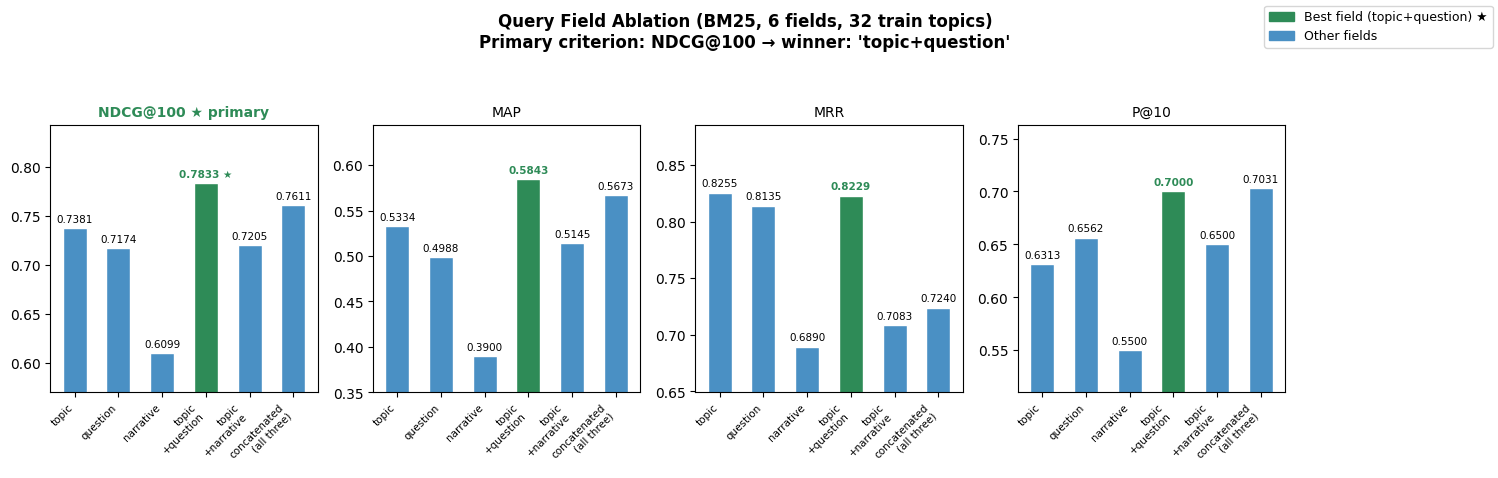

In [7]:
from src.tuning import field_ablation
from src.tuning.tuning_plots import plot_field_ablation

# Run BM25 with 6 query field variants on the 32 train topics.
best_field, ablation_results = field_ablation(
    client       = client,
    index_name   = index_name,
    all_doc_ids  = all_doc_ids,
    train_topics = train_topics,
    qrels        = qrels,
    qrels_graded = qrels_graded,
)

# ── Print results table cleanly ───────────────────────────────────────────────
print("\n" + "=" * 72)
print("Query Field Ablation  (BM25 default, 32 train topics)")
print("  Primary criterion: NDCG@100  |  Secondary (shown): MAP, MRR, P@10")
print("=" * 72)
print(f"{'Field':>20} | {'NDCG@100':>9} | {'MAP':>8} | {'MRR':>8} | {'P@10':>8}")
print("-" * 72)
for field, r in ablation_results.items():
    mark = " ★" if field == best_field else ""
    print(f"{field + mark:>20} | {r['NDCG@100']:>9.4f} | {r['MAP']:>8.4f} | {r['MRR']:>8.4f} | {r['P@10']:>8.4f}")
print("-" * 72)
print(f"\n  --> Best field: '{best_field}'  (NDCG@100={ablation_results[best_field]['NDCG@100']:.4f})")
print(f"  --> Locking '{best_field}' for all subsequent evaluations.")

# ── Update the module-level constant so all §3 sweep cells pick it up ────────
BEST_QUERY_FIELD = best_field   # overrides the default set in the constants cell
print(f"\n  BEST_QUERY_FIELD = '{BEST_QUERY_FIELD}'  (constant updated from live ablation result)")

fig = plot_field_ablation(
    ablation_results,
    primary_metric = "NDCG@100",
    save_path      = TUNING_DIR / "field_ablation.png" if CORPUS_SIZE is None else None,
)
display(fig)


---
## 3.3. BM25   k1, b Parameter Tuning

**Parameters:**
- **k1** — TF saturation: controls how much a term's score grows with repetition. `k1=0.5` → strong saturation (term appearing 5× ≈ appearing 2×). `k1=2.0` → repeated terms keep scoring much higher. For biomedical abstracts, clinical terms that repeat (e.g., "CPAP", "sleep apnea") are genuinely important signals — moderate-to-high k1 is expected to help.
- **b** — document length normalisation: `b=0` disables it; `b=1` fully normalises. PubMed abstracts are fairly uniform in length (mean=150 words, std≈100). The standard `b=0.75` penalises longer abstracts, but `b=1.0` works better here because comprehensive abstracts that cover a topic exhaustively (= long) should actually be preferred, not penalised.

**Selection criterion:** highest mean CV **NDCG@100** across 5 folds. MAP, MRR and P@10 are reported in the output table for reference.


BM25 (k1, b) sweep -- 24 configs x 5 folds  [sorted by NDCG@100]
  >> Best: k1=1.5, b=1.0  NDCG@100=0.7989  MAP=0.5961
[sweeper] Saved -> /content/nlp-biomedical-agent/results/phase1/tuning/bm25_param_sweep.csv


,k1,b,NDCG@100,±std,MAP,ΔNDCG
0,0.5,0.25,0.7650,0.0627,0.5650,-0.0251
1,0.5,0.50,0.7748,0.0563,0.5735,-0.0153
2,0.5,0.75,0.7780,0.0568,0.5780,-0.0121
3,0.5,1.00,0.7811,0.0564,0.5828,-0.0090
4,0.8,0.25,0.7722,0.0633,0.5743,-0.0179
5,0.8,0.50,0.7824,0.0545,0.5833,-0.0077
6,0.8,0.75,0.7839,0.0544,0.5866,-0.0062
7,0.8,1.00,0.7907,0.0521,0.5916,+0.0007
8,1.0,0.25,0.7765,0.0603,0.5776,-0.0136
9,1.0,0.50,0.7836,0.0550,0.5851,-0.0065


Saved: /content/nlp-biomedical-agent/results/phase1/tuning/bm25_param_sweep.png


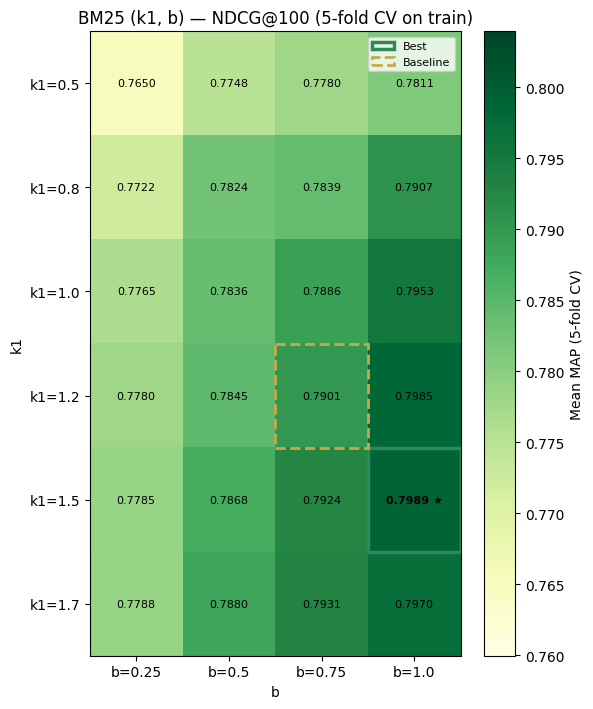

Locked: BM25_K1_B_BEST = k1=1.50, b=1.00


In [47]:
from src.tuning import run_bm25_sweep
from src.tuning.tuning_plots import plot_bm25_sweep

bm25 = run_bm25_sweep(
    client       = client,
    index_name   = index_name,
    train_topics = train_topics,
    qrels        = qrels,
    qrels_graded = qrels_graded,
    all_doc_ids  = all_doc_ids,
    k1_b_grid    = BM25_K1_B_GRID,
    n_folds      = N_CV_FOLDS,
    query_field  = best_field,
    output_csv   = TUNING_DIR / "bm25_param_sweep.csv" if CORPUS_SIZE is None else None,
)
display(bm25.to_dataframe())
fig = plot_bm25_sweep(bm25, save_path=TUNING_DIR / "bm25_param_sweep.png" if CORPUS_SIZE is None else None)
display(fig)

BM25_K1_B_BEST = (bm25.best["k1"], bm25.best["b"])
print(f"Locked: BM25_K1_B_BEST = k1={BM25_K1_B_BEST[0]:.2f}, b={BM25_K1_B_BEST[1]:.2f}")


---
## 3.4. LM-JM Lambda Selection

Using the locked query field (`topic+question`), we sweep **seven lambda values** — λ ∈ {0.1, 0.3, 0.5, 0.65, 0.7, 0.75, 0.9} — on the 32 train queries. The grid was extended (from the original {0.1, 0.3, 0.5, 0.7, 0.9}) by adding λ=0.65 and λ=0.75 to resolve the plateau region more precisely. The result is locked before touching the test set.

**Selection criterion:** highest mean CV **NDCG@100** across 5 folds. MAP and MRR are reported in the output table for reference.


LM-JM lambda sweep -- 7 values x 5 folds  [sorted by NDCG@100]
  >> Best: lambda=0.6500  NDCG@100=0.7754  MAP=0.5636
[sweeper] Saved -> /content/nlp-biomedical-agent/results/phase1/tuning/lmjm_lambda_sweep.csv


,λ,NDCG@100,±std,MAP,MRR,ΔNDCG
0,0.10,0.7351,0.0700,0.5231,0.8331,-0.0396
1,0.30,0.7555,0.0630,0.5462,0.8367,-0.0191
2,0.50,0.7719,0.0617,0.5600,0.8664,-0.0027
3,0.65,0.7754,0.0574,0.5636,0.8664,+0.0007
4,0.70,0.7746,0.0559,0.5634,0.8807,baseline
5,0.75,0.7750,0.0539,0.5634,0.8821,+0.0003
6,0.90,0.7744,0.0474,0.5610,0.8869,-0.0002


Saved: /content/nlp-biomedical-agent/results/phase1/tuning/lmjm_lambda_sweep.png


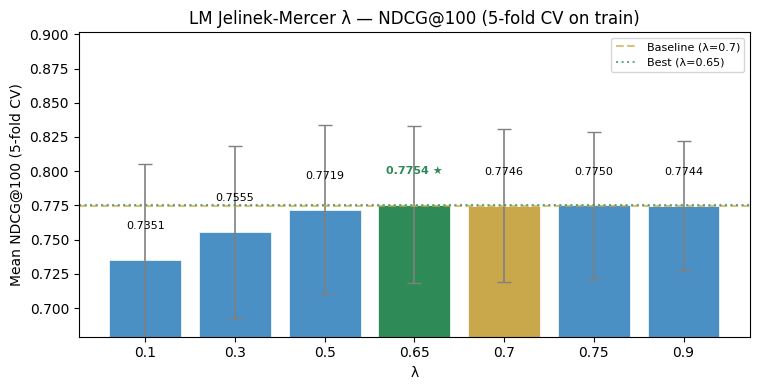

Locked: LMJM_LAMBDA_BEST = 0.65


In [48]:
from src.tuning import run_lmjm_sweep
from src.tuning.tuning_plots import plot_lmjm_sweep

lmjm = run_lmjm_sweep(
    client       = client,
    index_name   = index_name,
    train_topics = train_topics,
    qrels        = qrels,
    qrels_graded = qrels_graded,
    all_doc_ids  = all_doc_ids,
    lambdas      = LMJM_LAMBDAS_GRID,
    n_folds      = N_CV_FOLDS,
    query_field  = BEST_QUERY_FIELD,
    output_csv   = TUNING_DIR / "lmjm_lambda_sweep.csv" if CORPUS_SIZE is None else None,
)
display(lmjm.to_dataframe())
fig = plot_lmjm_sweep(lmjm, save_path=TUNING_DIR / "lmjm_lambda_sweep.png" if CORPUS_SIZE is None else None)
display(fig)

LMJM_LAMBDA_BEST = lmjm.best["lambda"]
print(f"Locked: LMJM_LAMBDA_BEST = {LMJM_LAMBDA_BEST:.2f}")


---
## 3.5. LM-Dirichlet μ Tuning

**Parameter:** μ (mu) in the Dirichlet smoothing formula.

For a normal corpus the default μ=2000 is often a good starting point, but it can be too high for short documents. We sweep μ ∈ {50, 75, 90, 100, 125, 200, 500, 1000, 2000} to find the optimal level of smoothing for our PubMed abstracts (mean length ≈150 words). The grid includes very low values to test if strong document-specificity helps, and high values to see if heavy smoothing is needed.

**Selection criterion:** highest mean CV **NDCG@100** across 5 folds. MAP and MRR are reported in the output table for reference.


LM-Dir mu sweep -- 9 values x 5 folds  [sorted by NDCG@100]
  >> Best: mu=100  NDCG@100=0.7706  MAP=0.5618
[sweeper] Saved -> /content/nlp-biomedical-agent/results/phase1/tuning/lmdir_mu_sweep.csv


,μ,NDCG@100,±std,MAP,MRR,ΔNDCG
0,50,0.7683,0.0601,0.5615,0.8417,+0.0173
1,75,0.7693,0.0590,0.5610,0.8607,+0.0183
2,90,0.7686,0.0598,0.5602,0.8607,+0.0176
3,100,0.7706,0.0588,0.5618,0.8750,+0.0196
4,125,0.7692,0.0592,0.5606,0.8607,+0.0182
5,200,0.7691,0.0606,0.5606,0.8714,+0.0181
6,500,0.7639,0.0597,0.5528,0.8786,+0.0129
7,1000,0.7562,0.0578,0.5461,0.8690,+0.0053
8,2000,0.7510,0.0584,0.5399,0.8690,baseline


Saved: /content/nlp-biomedical-agent/results/phase1/tuning/lmdir_mu_sweep.png


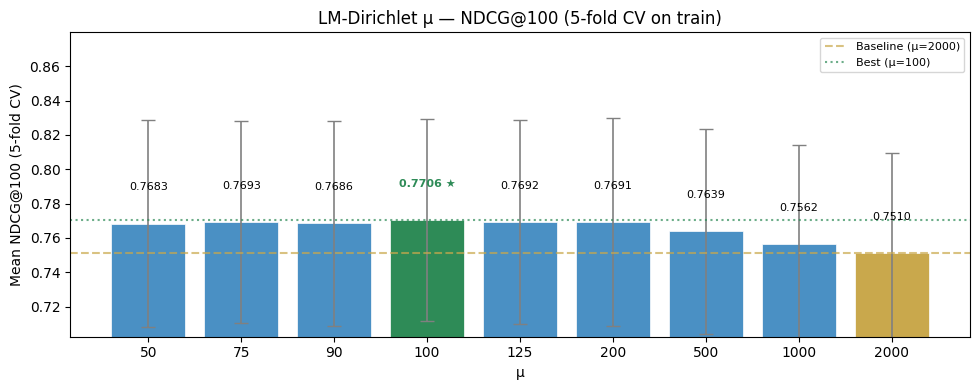

Locked: LMDIR_MU_BEST = 100


In [49]:
from src.tuning import run_lmdir_sweep
from src.tuning.tuning_plots import plot_lmdir_sweep

lmdir = run_lmdir_sweep(
    client       = client,
    index_name   = index_name,
    train_topics = train_topics,
    qrels        = qrels,
    qrels_graded = qrels_graded,
    all_doc_ids  = all_doc_ids,
    mus          = LMDIR_MU_GRID,
    n_folds      = N_CV_FOLDS,
    query_field  = best_field,
    output_csv   = TUNING_DIR / "lmdir_mu_sweep.csv" if CORPUS_SIZE is None else None,
)
display(lmdir.to_dataframe())
fig = plot_lmdir_sweep(lmdir, save_path=TUNING_DIR / "lmdir_mu_sweep.png" if CORPUS_SIZE is None else None)
display(fig)

LMDIR_MU_BEST = lmdir.best["mu"]
print(f"Locked: LMDIR_MU_BEST = {LMDIR_MU_BEST}")


---
## 3.6. Dense Encoder Comparison

In this section we analyse and commpare 4 different dense encoders:

**msmarco-distilbert-base-v2** ([HuggingFace](https://huggingface.co/sentence-transformers/msmarco-distilbert-base-v2))
- DistilBERT fine-tuned on MS MARCO: ~8.8 million (Bing search query, web passage) pairs.
- General-domain; not trained on biomedical text — domain mismatch with our task.
- Outputs a **768-dim** L2-normalised sentence vector.
- Stored in field `embedding_msmarco`.

**ncbi/MedCPT-Query-Encoder** + `MedCPT-Article-Encoder` ([HuggingFace](https://huggingface.co/ncbi/MedCPT-Query-Encoder))
- Medical Contrastive Pre-Training (MedCPT) by NCBI.
- Trained on 23 million PubMed search query → article click-through pairs.
- Exact domain match with our task (biomedical queries and PubMed abstracts).
- Asymmetric dual encoders: `MedCPT-Query-Encoder` for queries, `MedCPT-Article-Encoder` for abstracts. Both map to the same 768-dim space. How it works: the query encoder is trained to map search queries to vectors close to the article vectors of clicked abstracts, and far from non-clicked abstracts.
- This matters because abstracts (150 words) and queries (5–50 words) are very different lengths.
- Designed for zero-shot retrieval without fine-tuning.
- Stored in fields `embedding_medcpt_query` and `embedding_medcpt_article`.

**multi-qa-mpnet-base-cos-v1** ([HuggingFace](https://huggingface.co/sentence-transformers/multi-qa-mpnet-base-cos-v1))
- MPNet fine-tuned on 215 million question-answer pairs from StackExchange, Yahoo Answers, MS MARCO, and more.
- General-domain but trained on QA pairs — expected to handle question-format queries better than a general passage encoder.
- Outputs a 768-dim L2-normalised vector.
- Stored in field `embedding_mpnet`.


**Speccter2** ([HuggingFace](https://huggingface.co/allenai/specter2_base))
- Contrastive sentence encoder trained on citation pairs from Semantic Scholar.
- Multi-domain science, including biomedical papers.
- Outputs a 768-dim L2-normalised vector.
- Stored in field `embedding_specter2`.
  

---
### 3.6.1 — Pooling Mode Comparison: CLS vs Mean vs Mean-No-Special

### Mean Pooling

During the embedding process, BERT-based models produce one vector per input **token**, plus 1 CLS token possibly trained to capture the full sequence oof tokens (512 tokens per sequence). So to capture the full "meaning" of the query or abstract and obtain a single fixed-size embedding vector we use **mean pooling**: average the token vectors, disregarding the possible Padding tokens if the sequence doesn't ooccupy the full 512 tokens:

$$\mathbf{e} = \frac{\sum_i m_i \cdot \mathbf{h}_i}{\sum_i m_i}$$

where $\mathbf{h}_i$ is the hidden state of token $i$ from the **last hidden layer**, and $m_i \in \{0, 1\}$ is the attention mask (1 for real tokens, 0 for PAD). The result is then L2-normalised to unit length.

**Which tokens to pull?**
Besides the real tokens embeding vetors, we have special vectors including `[CLS]` at position 0 and `[SEP]` at the last position. With the previou mask we also capture these special tokens.

So we need to confirm what gives us the best results, acccording to the model. Some models like MedCPT were trained to embed in the CLS vector the best representation for the sequence, while others used the CLS vector to embed the sequence classification for NSP (next-sentence prediction), which might not actually capture in the best way the sequence meaning for retrieval tasks.

---

**Testes conducted:**

Following the normal pipeeline for the embedding process:
`Text input  →  Tokenizer  →  BERT layers  →  last_hidden_state (batch × seq_len × 768)`

We implemented tests to compare different pooling methods:
- CLS pooling (only CLS vector: last_hidden_state[:, 0, :])
- mean pooling (CLS + SEP + real tokens)
- mean_no_special (real tokens)

Then L2-normalize to achieve 768-dim unit vector, and then, instead of uploading all these new fields to OpenSearch and then use HNSW, we implemented the cosine similarity comparison direectly in Python.

We run **5 models × 3 pooling modes = 15 combinations**, comparing with NDCG@100 on the train set.

[FULL] Using full corpus: 4194 docs
Queries: 32
Sample query: runx2 mutations What will mutation in runx2 affect in the future?

Encoder setup:
  msmarco        doc=sentence-transformers/msmarco-distilbert-base-v2  |  query=sentence-transformers/msmarco-distilbert-base-v2
  medcpt         doc=ncbi/MedCPT-Article-Encoder  |  query=ncbi/MedCPT-Query-Encoder
  multi-qa       doc=sentence-transformers/multi-qa-mpnet-base-cos-v1  |  query=sentence-transformers/multi-qa-mpnet-base-cos-v1
  specter2       doc=allenai/specter2_base  |  query=allenai/specter2_base

-- msmarco | pooling=mean --
   doc_vecs  shape=(4194, 768)
   qry_vecs  shape=(32, 768)
   NDCG@100 = 0.7411  (32 queries scored)

-- msmarco | pooling=mean_no_special --
[encoder] Loading 'sentence-transformers/msmarco-distilbert-base-v2' on cuda (pooling=mean_no_special) ...


The following layers were not sharded: embeddings.LayerNorm.weight, embeddings.LayerNorm.bias, transformer.layer.*.attention.q_lin.bias, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.ffn.lin2.bias, transformer.layer.*.output_layer_norm.bias, transformer.layer.*.ffn.lin1.bias, embeddings.word_embeddings.weight, transformer.layer.*.ffn.lin2.weight, transformer.layer.*.output_layer_norm.weight, transformer.layer.*.sa_layer_norm.bias, embeddings.position_embeddings.weight, transformer.layer.*.ffn.lin1.weight, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.attention.out_lin.weight, transformer.layer.*.sa_layer_norm.weight, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.attention.out_lin.bias


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[encoder] Model loaded. Hidden size: 768
   doc_vecs  shape=(4194, 768)
   qry_vecs  shape=(32, 768)
   NDCG@100 = 0.7439  (32 queries scored)

-- msmarco | pooling=cls --
[encoder] Loading 'sentence-transformers/msmarco-distilbert-base-v2' on cuda (pooling=cls) ...


The following layers were not sharded: embeddings.LayerNorm.weight, embeddings.LayerNorm.bias, transformer.layer.*.attention.q_lin.bias, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.ffn.lin2.bias, transformer.layer.*.output_layer_norm.bias, transformer.layer.*.ffn.lin1.bias, embeddings.word_embeddings.weight, transformer.layer.*.ffn.lin2.weight, transformer.layer.*.output_layer_norm.weight, transformer.layer.*.sa_layer_norm.bias, embeddings.position_embeddings.weight, transformer.layer.*.ffn.lin1.weight, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.attention.out_lin.weight, transformer.layer.*.sa_layer_norm.weight, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.attention.out_lin.bias


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[encoder] Model loaded. Hidden size: 768
   doc_vecs  shape=(4194, 768)
   qry_vecs  shape=(32, 768)
   NDCG@100 = 0.7157  (32 queries scored)

-- specter2 | pooling=cls --
[encoder] Loading 'allenai/specter2_base' on cuda (pooling=cls) ...


The following layers were not sharded: embeddings.LayerNorm.weight, encoder.layer.*.attention.self.value.weight, embeddings.LayerNorm.bias, encoder.layer.*.output.dense.bias, encoder.layer.*.attention.output.dense.weight, encoder.layer.*.attention.output.dense.bias, pooler.dense.weight, pooler.dense.bias, encoder.layer.*.attention.output.LayerNorm.bias, encoder.layer.*.attention.self.query.weight, encoder.layer.*.attention.self.key.bias, encoder.layer.*.intermediate.dense.bias, embeddings.word_embeddings.weight, encoder.layer.*.output.LayerNorm.weight, encoder.layer.*.intermediate.dense.weight, embeddings.position_embeddings.weight, embeddings.token_type_embeddings.weight, encoder.layer.*.attention.self.key.weight, encoder.layer.*.attention.self.value.bias, encoder.layer.*.output.dense.weight, encoder.layer.*.attention.self.query.bias, encoder.layer.*.attention.output.LayerNorm.weight, encoder.layer.*.output.LayerNorm.bias


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[encoder] Model loaded. Hidden size: 768
   doc_vecs  shape=(4194, 768)
   qry_vecs  shape=(32, 768)
   NDCG@100 = 0.8269  (32 queries scored)


  §3.6.1. Results — NDCG@100 per (encoder x pooling mode)
Encoder                  mean    mean_no_special        cls
-----------------------------------------------------------
msmarco                0.7411             0.7439     0.5763
medcpt                 0.8203             0.8159     0.8374
multi-qa               0.8219             0.8228     0.7836
specter2               0.7258             0.7157     0.8269

Best combo: medcpt + cls -> NDCG@100 = 0.8374
MedCPT CLS vs Mean: +0.0172  (CLS wins -- official pooling confirmed)

Figure saved -> results/phase1/figures/pooling_comparison.png


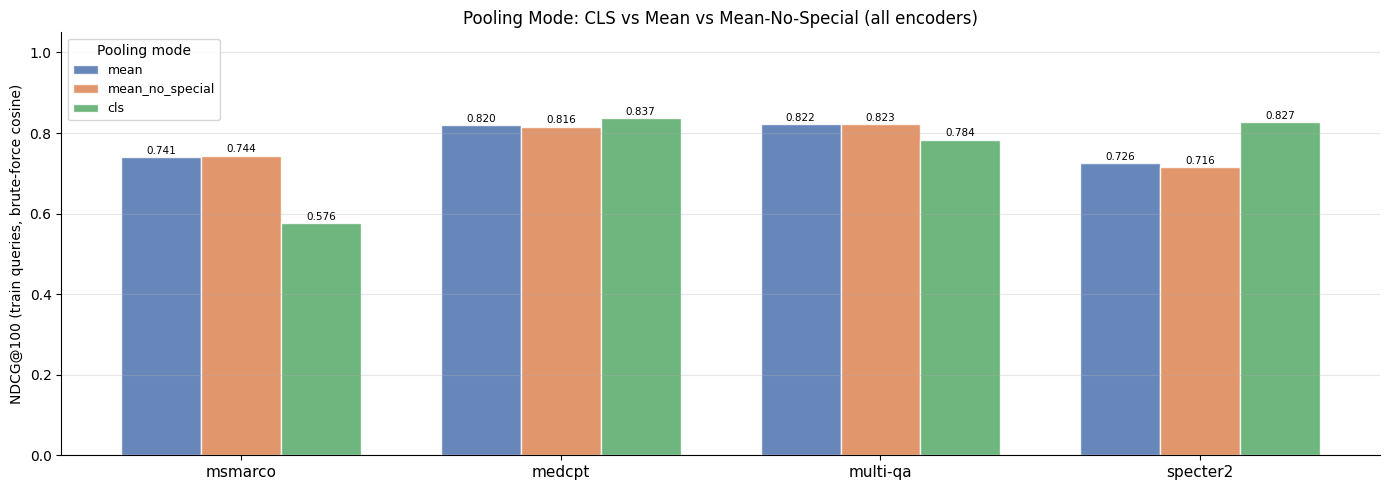


Done.


In [50]:
import math
import numpy as np
import matplotlib.pyplot as plt

from src.embeddings.encoder import Encoder, POOLING_MEAN, POOLING_MEAN_NO_SPECIAL, POOLING_CLS
from src.data.query_builder import build_query

# Use the given size of the corpus (smaller size for testing time)
if CORPUS_SIZE is not None:
    corpus_subset = corpus[:CORPUS_SIZE]
    print(f"[LOCAL] Using corpus subset: {len(corpus_subset)} docs (CORPUS_SIZE={CORPUS_SIZE})")
else:
    corpus_subset = corpus
    print(f"[FULL] Using full corpus: {len(corpus_subset)} docs")

corpus_ids   = [d["id"] for d in corpus_subset]
corpus_texts = [d["contents"] for d in corpus_subset]

# Build query texts from train_topics using the locked BEST_QUERY_FIELD
query_tid_list  = [str(t["id"]) for t in train_topics]
query_text_list = [build_query(t, BEST_QUERY_FIELD) for t in train_topics]

print(f"Queries: {len(query_text_list)}")
print(f"Sample query: {query_text_list[0][:80]}")

# encoder_defs maps alias -> (doc_model, query_model)
# MedCPT uses different models for docs vs queries (asymmetric dual-encoder):
#   - ncbi/MedCPT-Article-Encoder for corpus documents
#   - ncbi/MedCPT-Query-Encoder   for search queries
# All other models use the same model for both.
_MEDCPT_ARTICLE_MODEL = "ncbi/MedCPT-Article-Encoder"
_MEDCPT_QUERY_MODEL   = "ncbi/MedCPT-Query-Encoder"
encoder_defs = {}
for alias, model_name, _dim in ENCODERS_LIST:
    if alias == "medcpt":
        encoder_defs[alias] = (_MEDCPT_ARTICLE_MODEL, _MEDCPT_QUERY_MODEL)
    else:
        encoder_defs[alias] = (model_name, model_name)
print("\nEncoder setup:")
for alias, (doc_m, qry_m) in encoder_defs.items():
    print(f"  {alias:<14} doc={doc_m}  |  query={qry_m}")

# NDCG@100 helper (pure-Python cosine brute-force)
def cosine_rank(query_vec: np.ndarray, doc_vecs: np.ndarray, doc_ids: list) -> list:
    """Return [(doc_id, cosine_score), ...] sorted descending. Vecs must be L2-normalised."""
    scores = doc_vecs @ query_vec           # dot product = cosine when unit vectors
    order  = np.argsort(-scores)
    return [(doc_ids[i], float(scores[i])) for i in order]

def ndcg_at_100(ranked: list, qrel: dict, k: int = 100) -> float:
    """run_topic = [(pmid, score), ...] ranked list."""
    actual_rels = [qrel.get(pmid, 0) for pmid, _ in ranked[:k]]
    dcg   = sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(actual_rels) if r > 0)
    ideal = sorted(qrel.values(), reverse=True)
    idcg  = sum((2**r - 1) / math.log2(i + 2) for i, r in enumerate(ideal[:k]) if r > 0)
    return dcg / idcg if idcg > 0 else 0.0

# Evaluate all (encoder x pooling) combinations
POOLING_MODES = [
    (POOLING_MEAN,            "mean"),
    (POOLING_MEAN_NO_SPECIAL, "mean_no_special"),
    (POOLING_CLS,             "cls"),
]

results_36b = {}   # {(alias, pooling_label): mean_ndcg}

for alias, (doc_model, qry_model) in encoder_defs.items():
    for pooling_mode, pooling_label in POOLING_MODES:
        combo_key = (alias, pooling_label)
        print(f"\n-- {alias} | pooling={pooling_label} --")

        # Encode corpus docs
        doc_enc  = Encoder(doc_model, pooling_mode=pooling_mode)
        doc_vecs = doc_enc.encode(corpus_texts)           # (N, 768), L2-normalised
        print(f"   doc_vecs  shape={doc_vecs.shape}")

        # Encode queries
        qry_enc   = Encoder(qry_model, pooling_mode=pooling_mode)
        qry_vecs  = qry_enc.encode(query_text_list)       # (Q, 768), L2-normalised
        print(f"   qry_vecs  shape={qry_vecs.shape}")

        # Compute NDCG@100 per query
        ndcg_scores = []
        for i, tid in enumerate(query_tid_list):
            qrel = qrels_graded.get(tid, {})
            if not qrel:
                continue
            ranked = cosine_rank(qry_vecs[i], doc_vecs, corpus_ids)
            ndcg_scores.append(ndcg_at_100(ranked, qrel, k=100))

        mean_val = float(np.mean(ndcg_scores)) if ndcg_scores else 0.0
        results_36b[combo_key] = mean_val
        print(f"   NDCG@100 = {mean_val:.4f}  ({len(ndcg_scores)} queries scored)")

# Results table
print("\n\n====================================================================")
print("  §3.6.1. Results — NDCG@100 per (encoder x pooling mode)")
print("=====================================================================")
header = f"{'Encoder':<18} {'mean':>10} {'mean_no_special':>18} {'cls':>10}"
print(header)
print("-" * len(header))
for alias in encoder_defs:
    row = [results_36b.get((alias, pl), float("nan")) for _, pl in POOLING_MODES]
    print(f"{alias:<18} {row[0]:>10.4f} {row[1]:>18.4f} {row[2]:>10.4f}")

best_combo = max(results_36b, key=results_36b.get)
print(f"\nBest combo: {best_combo[0]} + {best_combo[1]} -> NDCG@100 = {results_36b[best_combo]:.4f}")
ref_medcpt_mean = results_36b.get(("medcpt", "mean"), None)
ref_medcpt_cls  = results_36b.get(("medcpt", "cls"),  None)
if ref_medcpt_mean and ref_medcpt_cls:
    delta = ref_medcpt_cls - ref_medcpt_mean
    sign  = "+" if delta >= 0 else ""
    print(f"MedCPT CLS vs Mean: {sign}{delta:.4f}  "
          f"({'CLS wins -- official pooling confirmed' if delta > 0 else 'mean OK or better -- investigate'})")

# Bar chart
aliases        = list(encoder_defs.keys())
pooling_labels = [pl for _, pl in POOLING_MODES]
x      = np.arange(len(aliases))
width  = 0.25
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(14, 5))
for i, (pl, color) in enumerate(zip(pooling_labels, colors)):
    vals = [results_36b.get((alias, pl), 0) for alias in aliases]
    bars = ax.bar(x + (i - 1) * width, vals, width, label=pl, color=color, alpha=0.85, edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(aliases, fontsize=11)
ax.set_ylabel("NDCG@100 (train queries, brute-force cosine)")
ax.set_title("Pooling Mode: CLS vs Mean vs Mean-No-Special (all encoders)")
ax.legend(title="Pooling mode", fontsize=9)
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()

save_path = Path("results/phase1/figures/pooling_comparison.png")
save_path.parent.mkdir(parents=True, exist_ok=True)
if CORPUS_SIZE is None:
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    print(f"\nFigure saved -> {save_path}")

plt.show()
print("\nDone.")


---
### 3.6.2 Dense Encoder Comparison

We encode all 4.194 corpus docs with each encoder's **document model**, then brute-force rank by cosine similarity for each query. This is 100% exact (no HNSW approximation error) and runs fast enough on GPU.

**Selection criterion:** highest mean CV **NDCG@100** across 5 folds. MAP, MRR and P@10 are reported in the output table for reference.

[msmarco] Query embeddings loaded from cache  shape=(32, 768)
[medcpt] Query embeddings loaded from cache  shape=(32, 768)
[multi-qa] Query embeddings loaded from cache  shape=(32, 768)
[specter2] Encoding 32 queries with 'allenai/specter2_base' ...
[specter2] Cached → specter2_queries_topic+question.npy  shape=(32, 768)
Encoder sweep -- 4 encoder(s)  [sorted by NDCG@100]
  >> Best: medcpt  NDCG@100=0.8273  MAP=0.6209
[sweeper] Saved -> /content/nlp-biomedical-agent/results/phase1/tuning/encoder_comparison.csv


,Encoder,NDCG@100,MAP,MRR,P@10,ΔNDCG
0,medcpt,0.8273,0.6209,0.8802,0.7094,+0.0825
1,multi-qa,0.8236,0.6435,0.8698,0.7719,+0.0789
2,msmarco,0.7448,0.5403,0.8568,0.7469,baseline
3,specter2,0.7292,0.5177,0.8854,0.7500,-0.0156


Saved: /content/nlp-biomedical-agent/results/phase1/tuning/encoder_comparison.png


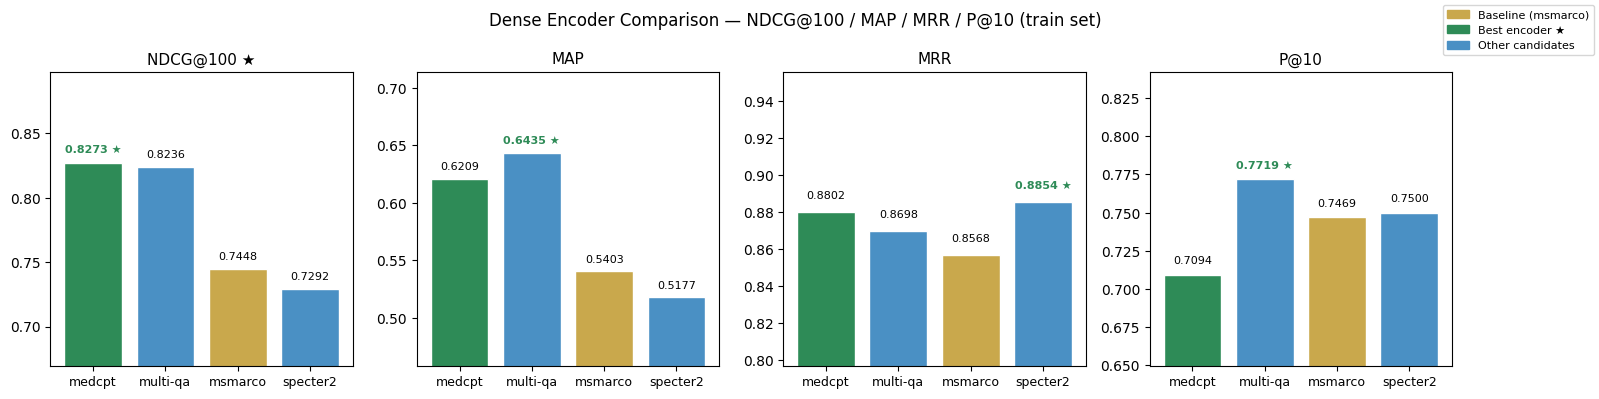

Locked: ENCODER_BEST = medcpt


In [51]:
from src.tuning import run_encoder_sweep
from src.tuning.tuning_plots import plot_encoder_sweep

enc_sweep = run_encoder_sweep(
    train_topics    = train_topics,
    qrels           = qrels,
    qrels_graded    = qrels_graded,
    all_doc_ids     = all_doc_ids,
    embeddings_list = embeddings_list,
    query_field     = BEST_QUERY_FIELD,
    cache_dir       = TUNING_DIR / "embeddings",
    force_reencode  = FORCE_REENCODE,
    batch_size      = ENCODE_BATCH_SIZE,
    output_csv      = TUNING_DIR / "encoder_comparison.csv" if CORPUS_SIZE is None else None,
)
display(enc_sweep.to_dataframe())
fig = plot_encoder_sweep(enc_sweep, save_path=TUNING_DIR / "encoder_comparison.png" if CORPUS_SIZE is None else None)
display(fig)

ENCODER_BEST = next(
    (alias, model_name, dim)
    for alias, model_name, dim in ENCODERS_LIST
    if alias == enc_sweep.best["alias"]
)
print(f"Locked: ENCODER_BEST = {ENCODER_BEST[0]}")


---
## 3.7 — Tuning Summary & Locked Configuration

In the next cell we present a summary of the findings.

Still remains to see next if the best solor models (BM25, LM-JM, LM-Dir, KNN) can be effectively combined with RRF fusion to further boost retrieval quality.

[plots] Saved tuning summary -> /content/nlp-biomedical-agent/results/phase1/tuning/tuning_summary.png


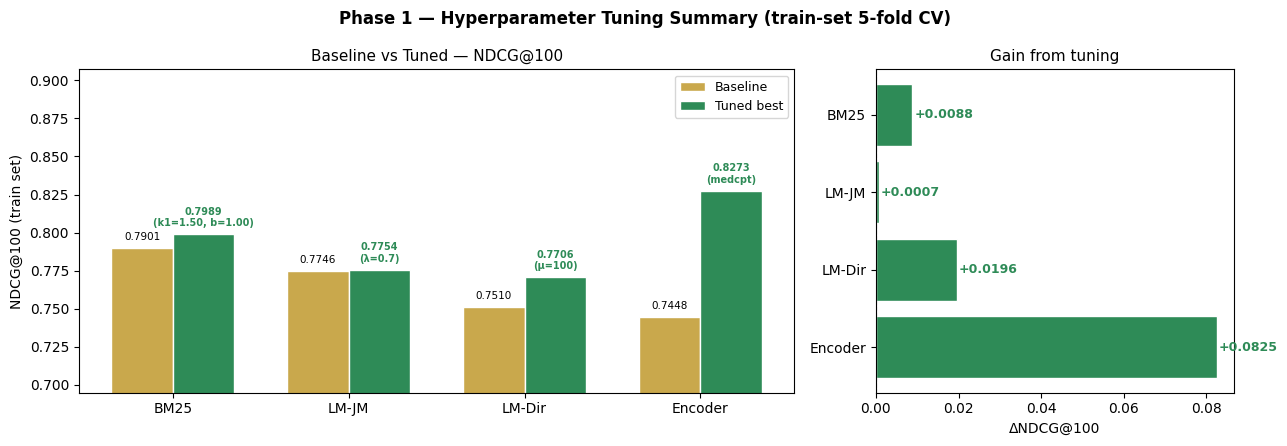

,Parameter,Baseline,Best,ΔNDCG@100
Model,,,,
BM25,"k1, b","k1=1.20, b=0.75","k1=1.50, b=1.00",+0.0088
LM-JM,λ,λ=0.7,λ=0.7,+0.0007
LM-Dirichlet,μ,μ=2000,μ=100,+0.0196
Dense Encoder,encoder,msmarco,medcpt,+0.0825



  All subsequent evaluations use the 'Best' config above.
  Query field locked to: 'topic+question'  (§3.2 ablation)


In [52]:
import pandas as pd
from src.tuning.tuning_plots import plot_tuning_summary


# ── Visual summary: baseline vs tuned NDCG@100 for every model ────────────────
fig = plot_tuning_summary(
    bm25      = bm25,
    lmjm      = lmjm,
    lmdir     = lmdir,
    enc_sweep = enc_sweep,
    save_path = TUNING_DIR / "tuning_summary.png" if CORPUS_SIZE is None else None,
)
display(fig)

# Locked configuration table
_rows = [
    {"Model": "BM25",          "Parameter": "k1, b",    "Baseline": "k1=1.20, b=0.75",
     "Best": f"k1={bm25.best['k1']:.2f}, b={bm25.best['b']:.2f}",
     "ΔNDCG@100": f"{bm25.best['mean_ndcg'] - bm25.baseline()['mean_ndcg']:+.4f}"},
    {"Model": "LM-JM",         "Parameter": "λ",         "Baseline": "λ=0.7",
     "Best": f"λ={lmjm.best['lambda']:.1f}",
     "ΔNDCG@100": f"{lmjm.best['mean_ndcg'] - lmjm.baseline()['mean_ndcg']:+.4f}"},
    {"Model": "LM-Dirichlet",  "Parameter": "μ",         "Baseline": "μ=2000",
     "Best": f"μ={lmdir.best['mu']}",
     "ΔNDCG@100": f"{lmdir.best['mean_ndcg'] - lmdir.baseline()['mean_ndcg']:+.4f}"},
    {"Model": "Dense Encoder", "Parameter": "encoder",   "Baseline": "msmarco",
     "Best": enc_sweep.best["alias"],
     "ΔNDCG@100": f"{enc_sweep.best['ndcg'] - enc_sweep.baseline()['ndcg']:+.4f}"},
]
display(pd.DataFrame(_rows).set_index("Model"))
print("\n  All subsequent evaluations use the 'Best' config above.")
print("  Query field locked to: '{}'  (§3.2 ablation)".format(best_field))


---
## 3.8 — RRF Pair Grid Search

Reciprocal Rank Fusion (RRF) combines two ranked lists without requiring score calibration. Given that we now have tuned parameters for BM25, LM-JM, LM-Dir, and four dense encoders (MedCPT, multi-qa, msmarco, specter), the question is: **which pair of retrievers makes the best RRF fusion, and does the RRF smoothing constant k matter?**

**Strategy:** exhaustive grid over all interesting retriever pairs × a small set of k values (30 / 60 / 90) evaluated by 5-fold CV on the 32 train topics.  

We present a plot with all models, solo and rrf for better comparison.

Loading / reusing encoders ...
  medcpt  : ncbi/MedCPT-Query-Encoder
  msmarco : sentence-transformers/msmarco-distilbert-base-v2
  multi-qa: sentence-transformers/multi-qa-mpnet-base-cos-v1
  specter2: allenai/specter2_base

Solo reference scores (NDCG@100):
  BM25           0.7989
  LM-JM          0.7754
  LM-Dir         0.7706
  KNN(MedCPT)    0.8273

RRF pair sweep -- 9 pairs × 3 k-values × 5 folds  [sorted by NDCG@100]
  BM25 + KNN(MedCPT)  k=30          NDCG@100=0.5958  MAP=0.2892
  BM25 + KNN(MedCPT)  k=60          NDCG@100=0.5910  MAP=0.2892
  BM25 + KNN(MedCPT)  k=90          NDCG@100=0.5837  MAP=0.2854
  BM25 + LM-JM  k=30                NDCG@100=0.7880  MAP=0.5803
  BM25 + LM-JM  k=60                NDCG@100=0.7880  MAP=0.5805
  BM25 + LM-JM  k=90                NDCG@100=0.7880  MAP=0.5806
  BM25 + LM-Dir  k=30               NDCG@100=0.7906  MAP=0.5846
  BM25 + LM-Dir  k=60               NDCG@100=0.7907  MAP=0.5846
  BM25 + LM-Dir  k=90               NDCG@100=0.7907  MAP=0.5

,Pair,RRF k,NDCG@100,±std,MAP,MRR,P@10,ΔNDCG
0,BM25 + LM-Dir,90,0.7907,0.0512,0.5846,0.8988,0.7071,+0.1949
1,BM25 + LM-Dir,60,0.7907,0.0511,0.5846,0.8988,0.7071,+0.1948
2,BM25 + LM-Dir,30,0.7906,0.0509,0.5846,0.8988,0.7071,+0.1948
3,BM25 + LM-JM,60,0.7880,0.0509,0.5805,0.8807,0.6993,+0.1922
4,BM25 + LM-JM,90,0.7880,0.0510,0.5806,0.8807,0.6993,+0.1922
5,BM25 + LM-JM,30,0.7880,0.0508,0.5803,0.8807,0.6993,+0.1921
6,LM-JM + LM-Dir,30,0.7771,0.0567,0.5664,0.8845,0.7257,+0.1813
7,LM-JM + LM-Dir,60,0.7769,0.0569,0.5661,0.8845,0.7257,+0.1811
8,LM-JM + LM-Dir,90,0.7768,0.0570,0.5660,0.8845,0.7257,+0.1810
9,BM25 + KNN(MedCPT),30,0.5958,0.0603,0.2892,0.7899,0.3957,+0.0000



  --> Best RRF: 'BM25 + LM-Dir  k=90' (k=90)
      NDCG@100 = 0.7907  MAP = 0.5846  MRR = 0.8988  P@10 = 0.7071

  --> Locked: RRF_BEST_PAIR='BM25 + LM-Dir',  RRF_BEST_K=90

Overall leaderboard  (NDCG@100, train CV)
--------------------------------------------------
  1.  KNN(MedCPT)                              0.8273  <-- BEST
  2.  BM25                                     0.7989
  3.  RRF(BM25 + LM-Dir  k=90, k=90)           0.7907
  4.  LM-JM                                    0.7754
  5.  LM-Dir                                   0.7706
--------------------------------------------------

  Best solo  : KNN(MedCPT)  NDCG=0.8273
  Best RRF   : BM25 + LM-Dir  k=90 (k=90)  NDCG=0.7907
  Delta      : -0.0366  (solo wins)

  --> BEST OVERALL : 'KNN(MedCPT)'  NDCG@100 = 0.8273
  --> BEST_OVERALL_KEY (for §4 result dicts): 'knn_best'
[plots] Saved RRF sweep -> /content/nlp-biomedical-agent/results/phase1/tuning/rrf_pair_sweep.png


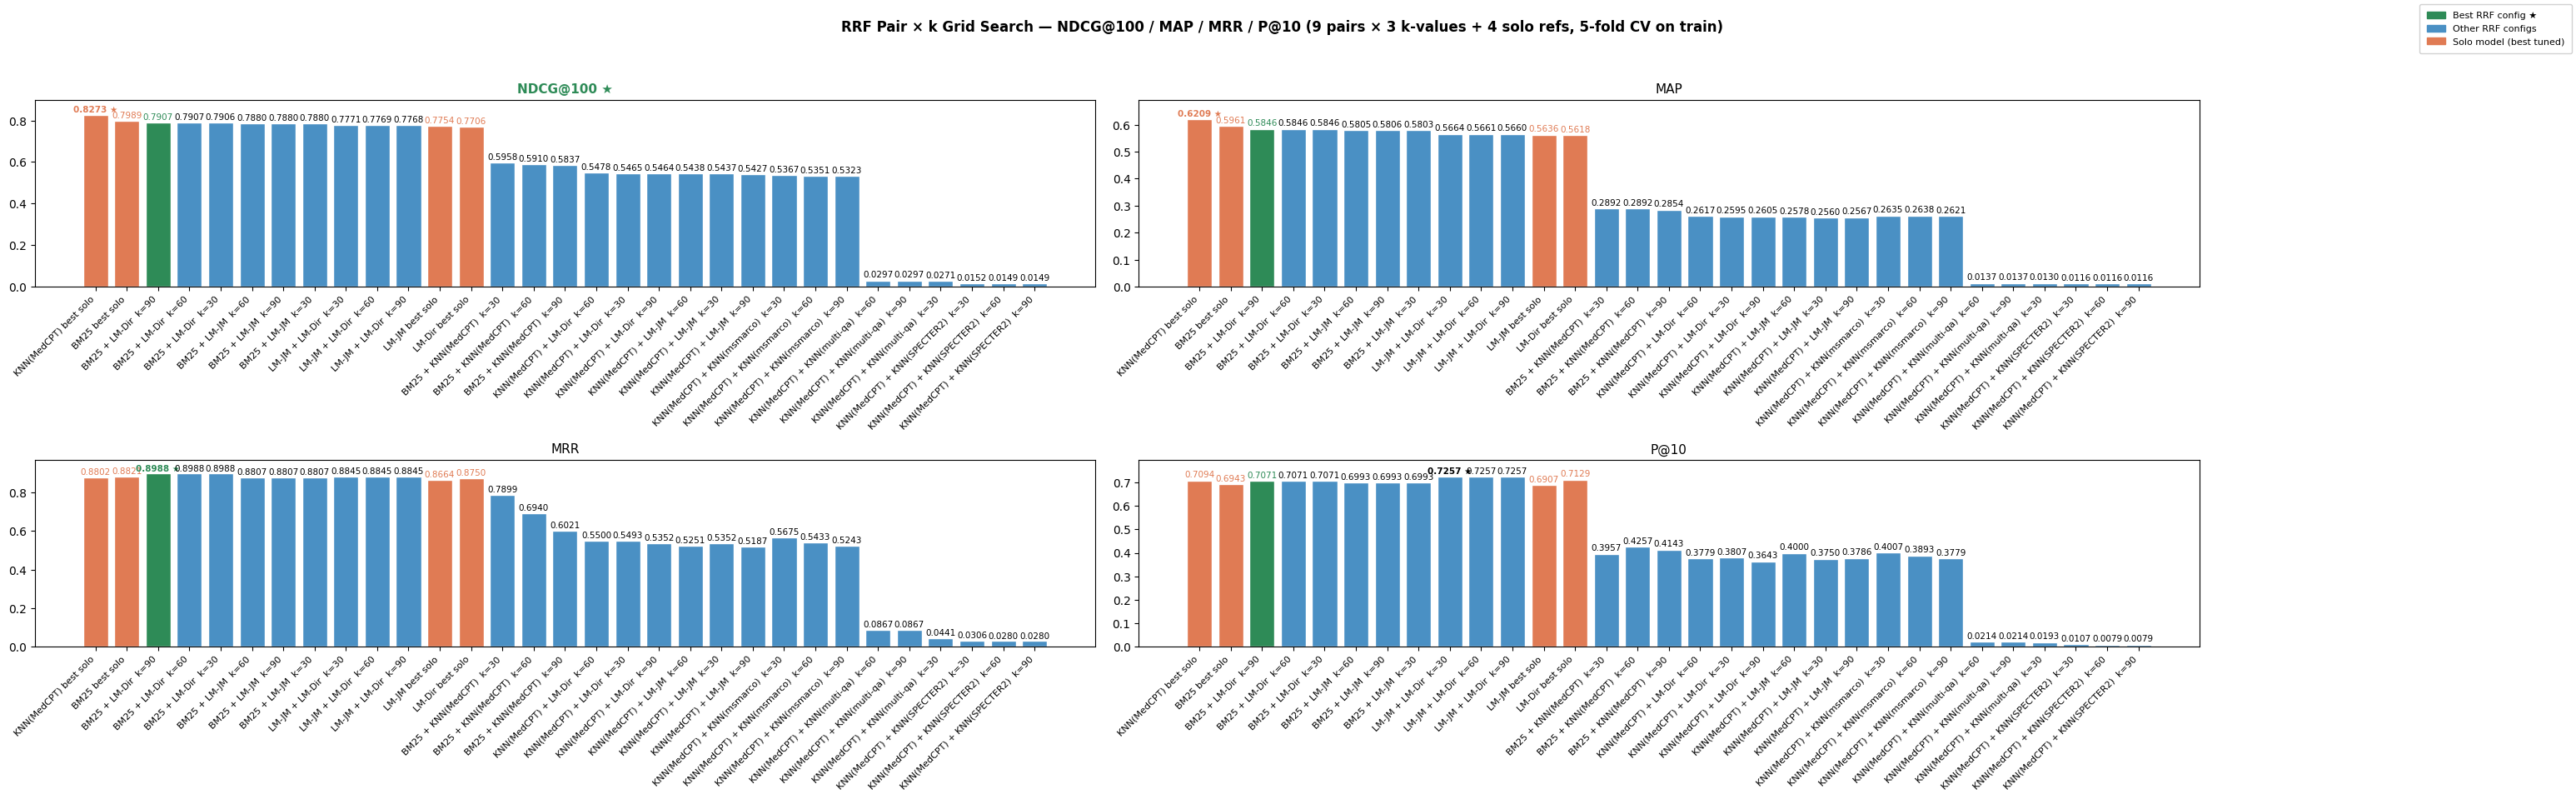

In [53]:
from src.tuning import run_rrf_sweep
from src.tuning.tuning_plots import plot_rrf_sweep
from src.retrieval.bm25 import BM25Retriever
from src.retrieval.lm_jelinek_mercer import LMJMRetriever
from src.retrieval.lm_dirichlet import LMDirichletRetriever
from src.retrieval.knn import KNNRetriever
from src.embeddings.encoder import Encoder

# ── Best tuned parameters (locked from §3.3 – 3.6) ──────────────────────────
_BM25_K1, _BM25_B  = BM25_K1_B_BEST
_LMJM_LAM          = LMJM_LAMBDA_BEST
_LMDIR_MU          = LMDIR_MU_BEST
_ENC_ALIAS, _ENC_MODEL, _ENC_DIM = ENCODER_BEST   # ("medcpt", ...)

# Load encoders once — Encoder() caches by alias, safe to call repeatedly
print("Loading / reusing encoders ...")
encoder_medcpt   = Encoder(ENCODER_BEST)
encoder_msmarco  = Encoder(ENCODER_MS_MARCO)
encoder_multiq   = Encoder(ENCODER_MULTI_QA)
encoder_specter2 = Encoder(ENCODER_SPECTER2)
print(f"  medcpt  : {_ENC_MODEL}")
print(f"  msmarco : {ENCODER_MS_MARCO[1]}")
print(f"  multi-qa: {ENCODER_MULTI_QA[1]}")
print(f"  specter2: {ENCODER_SPECTER2[1]}")

# Solo-model reference scores (from the individual tuning sweeps in §3.3 – 3.6)
_enc_best = enc_sweep.best
solo_scores = {
    "BM25":        {"ndcg": bm25.best["mean_ndcg"],  "map": bm25.best["mean_map"],
                    "mrr":  bm25.best["mean_mrr"],   "p10": bm25.best["mean_p10"]},
    "LM-JM":       {"ndcg": lmjm.best["mean_ndcg"],  "map": lmjm.best["mean_map"],
                    "mrr":  lmjm.best["mean_mrr"],   "p10": lmjm.best["mean_p10"]},
    "LM-Dir":      {"ndcg": lmdir.best["mean_ndcg"], "map": lmdir.best["mean_map"],
                    "mrr":  lmdir.best["mean_mrr"],  "p10": lmdir.best["mean_p10"]},
    "KNN(MedCPT)": {"ndcg": _enc_best["ndcg"],  "map": _enc_best["map"],
                    "mrr":  _enc_best["mrr"],   "p10": _enc_best["p10"]},
}
print("\nSolo reference scores (NDCG@100):")
for name, sc in solo_scores.items():
    print(f"  {name:<14} {sc['ndcg']:.4f}")

# Grid: pairs x RRF k values
RRF_K_GRID = [30, 60, 90]   # Cormack default = 60

pair_configs = [
    {
        "label":   "BM25 + KNN(MedCPT)",
        "factory": lambda: (
            BM25Retriever(client, index_name, k1=_BM25_K1, b=_BM25_B),
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
        ),
    },
    {
        "label":   "BM25 + LM-JM",
        "factory": lambda: (
            BM25Retriever(client, index_name, k1=_BM25_K1, b=_BM25_B),
            LMJMRetriever(client, index_name, lambd=_LMJM_LAM),
        ),
    },
    {
        "label":   "BM25 + LM-Dir",
        "factory": lambda: (
            BM25Retriever(client, index_name, k1=_BM25_K1, b=_BM25_B),
            LMDirichletRetriever(client, index_name, mu=_LMDIR_MU),
        ),
    },
    {
        "label":   "KNN(MedCPT) + LM-JM",
        "factory": lambda: (
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
            LMJMRetriever(client, index_name, lambd=_LMJM_LAM),
        ),
    },
    {
        "label":   "KNN(MedCPT) + LM-Dir",
        "factory": lambda: (
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
            LMDirichletRetriever(client, index_name, mu=_LMDIR_MU),
        ),
    },
    {
        "label":   "LM-JM + LM-Dir",
        "factory": lambda: (
            LMJMRetriever(client, index_name, lambd=_LMJM_LAM),
            LMDirichletRetriever(client, index_name, mu=_LMDIR_MU),
        ),
    },
    # KNN x KNN: do two dense encoders fuse well?
    {
        "label":   "KNN(MedCPT) + KNN(msmarco)",
        "factory": lambda: (
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
            KNNRetriever(client, index_name, encoder=encoder_msmarco),
        ),
    },
    {
        "label":   "KNN(MedCPT) + KNN(multi-qa)",
        "factory": lambda: (
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
            KNNRetriever(client, index_name, encoder=encoder_multiq),
        ),
    },
    {
        "label":   "KNN(MedCPT) + KNN(SPECTER2)",
        "factory": lambda: (
            KNNRetriever(client, index_name, encoder=encoder_medcpt),
            KNNRetriever(client, index_name, encoder=encoder_specter2),
        ),
    },
]

# Run sweep
rrf_sweep = run_rrf_sweep(
    client       = client,
    index_name   = index_name,
    train_topics = train_topics,
    qrels        = qrels,
    qrels_graded = qrels_graded,
    all_doc_ids  = all_doc_ids,
    pair_configs = pair_configs,
    rrf_k_grid   = RRF_K_GRID,
    n_folds      = N_CV_FOLDS,
    query_field  = BEST_QUERY_FIELD,
    solo_scores  = solo_scores,
    output_csv   = TUNING_DIR / "rrf_pair_sweep.csv" if CORPUS_SIZE is None else None,
)

# Print results table
print("\n" + "=" * 80)
print("RRF Results Table")
display(rrf_sweep.to_dataframe())

# Best RRF
best_rrf = rrf_sweep.best
print(f"\n  --> Best RRF: '{best_rrf['label']}' (k={best_rrf['rrf_k']})")
print(f"      NDCG@100 = {best_rrf['mean_ndcg']:.4f}  "
      f"MAP = {best_rrf['mean_map']:.4f}  "
      f"MRR = {best_rrf['mean_mrr']:.4f}  "
      f"P@10 = {best_rrf['mean_p10']:.4f}")

RRF_BEST_PAIR  = best_rrf["pair"]
RRF_BEST_K     = best_rrf["rrf_k"]
print(f"\n  --> Locked: RRF_BEST_PAIR='{RRF_BEST_PAIR}',  RRF_BEST_K={RRF_BEST_K}")

# ── Best overall: RRF vs all solo models ─────────────────────────────────────
# Build a unified leaderboard — solo models + best RRF — ranked by NDCG@100.
# _solo_key_map maps the solo display names (used in solo_scores) to the
# 'tuned_results' dict keys used in §4, so we can look up per-query data.
_solo_key_map = {
    "BM25":        "bm25_best",
    "LM-JM":       "lm_jm_best",
    "LM-Dir":      "lm_dir_best",
    "KNN(MedCPT)": "knn_best",
}

_candidates = {name: sc["ndcg"] for name, sc in solo_scores.items()}
_rrf_display_label = f"RRF({best_rrf['label']}, k={best_rrf['rrf_k']})"
_candidates[_rrf_display_label] = best_rrf["mean_ndcg"]

_ranked = sorted(_candidates.items(), key=lambda x: x[1], reverse=True)
BEST_OVERALL_STRAT = _ranked[0][0]   # human-readable label (for display / reports)
BEST_OVERALL_KEY   = _solo_key_map.get(BEST_OVERALL_STRAT, "rrf_best")
_overall_winner, _overall_ndcg = _ranked[0]

print("\n" + "=" * 80)
print("Overall leaderboard  (NDCG@100, train CV)")
print("-" * 50)
for rank, (name, ndcg) in enumerate(_ranked, 1):
    marker = "  <-- BEST" if rank == 1 else ""
    print(f"  {rank}.  {name:<40} {ndcg:.4f}{marker}")
print("-" * 50)

_rrf_ndcg       = best_rrf["mean_ndcg"]
_best_solo      = max(solo_scores.values(), key=lambda s: s["ndcg"])
_best_solo_name = max(solo_scores, key=lambda k: solo_scores[k]["ndcg"])
_delta          = _rrf_ndcg - _best_solo["ndcg"]
_sign           = "+" if _delta >= 0 else ""

print(f"\n  Best solo  : {_best_solo_name}  NDCG={_best_solo['ndcg']:.4f}")
print(f"  Best RRF   : {best_rrf['label']} (k={best_rrf['rrf_k']})  NDCG={_rrf_ndcg:.4f}")
print(f"  Delta      : {_sign}{_delta:.4f}  "
      f"({'RRF wins' if _delta > 0 else 'solo wins' if _delta < 0 else 'tie'})")
print(f"\n  --> BEST OVERALL : '{BEST_OVERALL_STRAT}'  NDCG@100 = {_overall_ndcg:.4f}")
print(f"  --> BEST_OVERALL_KEY (for §4 result dicts): '{BEST_OVERALL_KEY}'")

# Plot
fig_rrf = plot_rrf_sweep(
    rrf_sweep,
    save_path = TUNING_DIR / "rrf_pair_sweep.png" if CORPUS_SIZE is None else None,
)
display(fig_rrf)


---
# **4 — Final Evaluation on Test Set**

At this point **all configurations are locked with the best parameters**.

Now lets run besst model
Nothing is selected here — we simply apply each fixed configuration to the held-out 33-query test set and measure the outcome.

All runs use the `topic+question` query field locked in §3.2, and LM-JM **λ=0.65** locked in **§3.4**.

This section covers:
- §4.1: Run file generation on test set for both baseline and tuned models
- §4.2: Compare Baseline vs tuned models results on test set
- §4.3: Analyse PR curve for individual queries
- §4.4: Analyse PR curve and MAP for tuned models

---
## 4.1 — Run File Generation on Test Set

Search OpenSearch with each strategy (Baseline and Tuned), using the "BEST_QUERY_FIELD", and save results to analyse and compare later.

In [8]:
from src.evaluation.evaluator import evaluate_retriever, save_run
from src.retrieval.bm25 import BM25Retriever
from src.retrieval.lm_jelinek_mercer import LMJMRetriever
from src.retrieval.lm_dirichlet import LMDirichletRetriever
from src.retrieval.knn import KNNRetriever
from src.retrieval.rrf import RRFRetriever
from src.embeddings.encoder import Encoder

# -- Encoder instances (cached -- safe to call Encoder() multiple times) ----
enc_default = Encoder(ENCODER_MODEL_DEFAULT)
enc_best    = Encoder(ENCODER_BEST)

# Strategies (Baseline and Tuned)
_strategies = {
    # -- Baselines -----------------------------------------------------------
    "bm25_base":   BM25Retriever(client, index_name),
    "lm_jm_base":  LMJMRetriever(client, index_name, lambd=LMJM_LAMBDAS_DEFAULT[0]),
    "lm_dir_base": LMDirichletRetriever(client, index_name),
    "knn_base":    KNNRetriever(client, index_name, encoder=enc_default),
    "rrf_base":    RRFRetriever(
                       BM25Retriever(client, index_name),
                       KNNRetriever(client, index_name, encoder=enc_default),
                   ),
    # -- Tuned (locked best params from s3.3 - 3.6) -------------------------
    "bm25_best":   BM25Retriever(client, index_name,
                                 k1=BM25_K1_B_BEST[0], b=BM25_K1_B_BEST[1]),
    "lm_jm_best":  LMJMRetriever(client, index_name, lambd=LMJM_LAMBDA_BEST),
    "lm_dir_best": LMDirichletRetriever(client, index_name, mu=LMDIR_MU_BEST),
    "knn_best":    KNNRetriever(client, index_name, encoder=enc_best,
                                encoder_alias=ENCODER_BEST[0]),
    "rrf_best":    RRFRetriever(
                       BM25Retriever(client, index_name,
                                     k1=BM25_K1_B_BEST[0], b=BM25_K1_B_BEST[1]),
                       KNNRetriever(client, index_name, encoder=enc_best,
                                    encoder_alias=ENCODER_BEST[0]),
                       rrf_k=RRF_BEST_K,
                   ),
}

_BASELINE_KEYS = ["bm25_base", "lm_jm_base", "lm_dir_base", "knn_base", "rrf_base"]
_TUNED_KEYS    = ["bm25_best", "lm_jm_best", "lm_dir_best", "knn_best", "rrf_best"]

baseline_results = {}
tuned_results    = {}

for _name, _ret in _strategies.items():
    _out = PHASE1_RESULTS_DIR / f"{_name}_test_run.json"
    print(f"  Running {_name} ...", end="", flush=True)
    _r = evaluate_retriever(
        _ret, test_topics, qrels, qrels_graded, all_doc_ids,
        query_field=BEST_QUERY_FIELD,
        size=RETRIEVAL_SIZE,
    )
    save_run(_r["run"], _out)
    print(f"  NDCG@100={_r['NDCG@100']:.4f}  MAP={_r['MAP']:.4f}  "
          f"MRR={_r['MRR']:.4f}  P@10={_r['P@10']:.4f}")
    if _name in _BASELINE_KEYS:
        baseline_results[_name] = _r
    else:
        tuned_results[_name] = _r

print(f"\n  baseline_results keys : {list(baseline_results.keys())}")
print(f"  tuned_results    keys : {list(tuned_results.keys())}")


[encoder] Loading 'sentence-transformers/msmarco-distilbert-base-v2' on cuda (pooling=mean) ...


The following layers were not sharded: transformer.layer.*.output_layer_norm.bias, transformer.layer.*.attention.v_lin.weight, transformer.layer.*.ffn.lin1.weight, transformer.layer.*.attention.v_lin.bias, transformer.layer.*.attention.out_lin.bias, transformer.layer.*.sa_layer_norm.bias, transformer.layer.*.attention.k_lin.weight, transformer.layer.*.sa_layer_norm.weight, transformer.layer.*.attention.q_lin.weight, transformer.layer.*.ffn.lin2.weight, transformer.layer.*.ffn.lin2.bias, embeddings.LayerNorm.weight, embeddings.word_embeddings.weight, embeddings.position_embeddings.weight, transformer.layer.*.attention.q_lin.bias, embeddings.LayerNorm.bias, transformer.layer.*.output_layer_norm.weight, transformer.layer.*.attention.k_lin.bias, transformer.layer.*.ffn.lin1.bias, transformer.layer.*.attention.out_lin.weight


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[encoder] Model loaded. Hidden size: 768
  Running bm25_base ...  NDCG@100=0.7756  MAP=0.5695  MRR=0.7712  P@10=0.6333
  Running lm_jm_base ...  NDCG@100=0.7586  MAP=0.5431  MRR=0.7848  P@10=0.6333
  Running lm_dir_base ...  NDCG@100=0.7341  MAP=0.5149  MRR=0.7740  P@10=0.6212
  Running knn_base ...  NDCG@100=0.7576  MAP=0.5561  MRR=0.8384  P@10=0.6879
  Running rrf_base ...  NDCG@100=0.8114  MAP=0.6100  MRR=0.8141  P@10=0.6667
  Running bm25_best ...  NDCG@100=0.7742  MAP=0.5677  MRR=0.7141  P@10=0.6333
  Running lm_jm_best ...  NDCG@100=0.7569  MAP=0.5413  MRR=0.7864  P@10=0.6212
  Running lm_dir_best ...  NDCG@100=0.7555  MAP=0.5428  MRR=0.7773  P@10=0.6061
  Running knn_best ...  NDCG@100=0.8077  MAP=0.6143  MRR=0.8000  P@10=0.6788
  Running rrf_best ...  NDCG@100=0.8245  MAP=0.6266  MRR=0.8394  P@10=0.6515

  baseline_results keys : ['bm25_base', 'lm_jm_base', 'lm_dir_base', 'knn_base', 'rrf_base']
  tuned_results    keys : ['bm25_best', 'lm_jm_best', 'lm_dir_best', 'knn_best', 'r

---
## 4.2 — Baseline vs Tuned on Test Set

The plots below compare all strategies, comparing the baseline scores vs the tuned models scores, across the 5 metrics (`MAP`, `MRR`, `P@10`, `R@100`, `NDCG@100`).

- **Grouped bar chart** — baseline vs tuned model results for each metric.
- **Tuning gain chart** — delta NDCG@100 and delta MAP per model.

**NDCG@100 is the primary metric** for selecting the best model, but we report all 5 for a comprehensive view of retrieval quality.

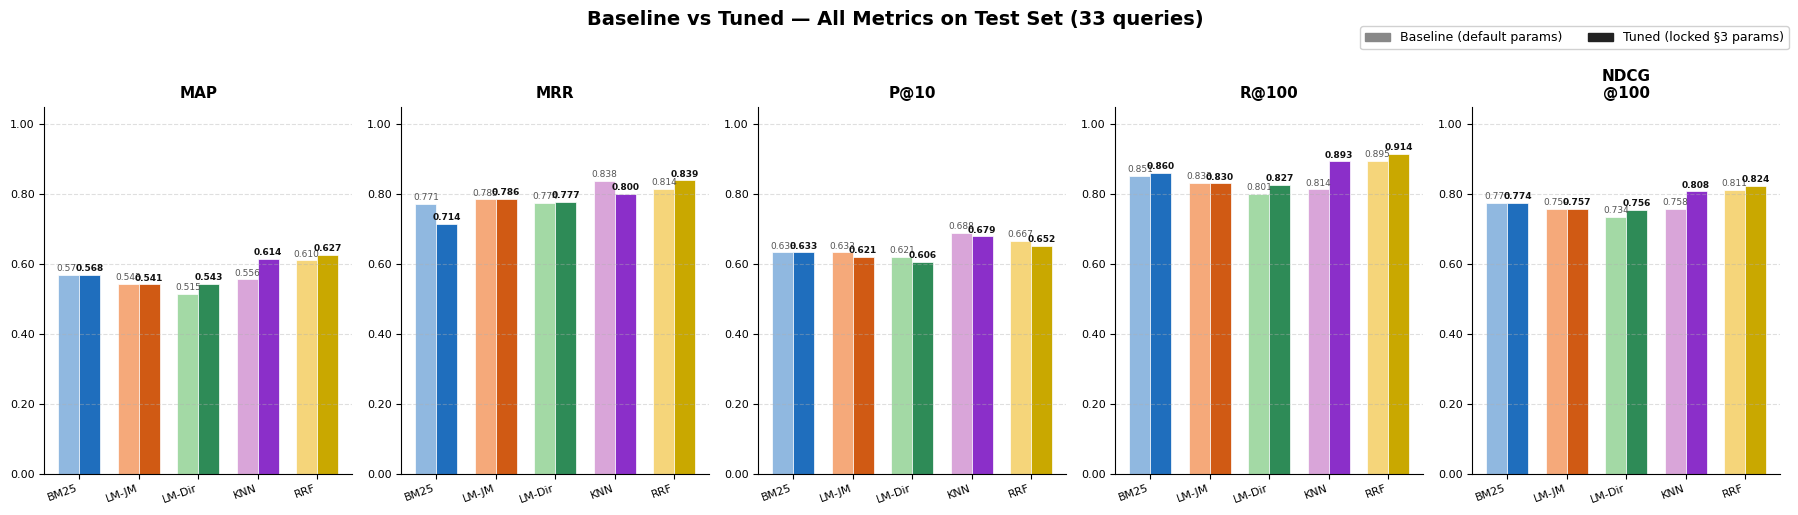

Saved: /content/nlp-biomedical-agent/results/phase1/baseline_vs_tuned_metrics.png


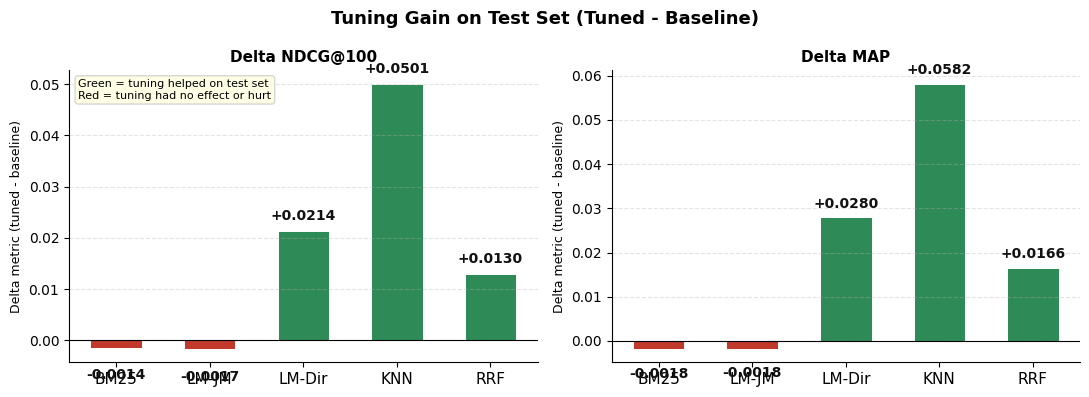

Saved: /content/nlp-biomedical-agent/results/phase1/tuning_gain_test.png

Key observations:
  BM25     delta_NDCG@100=-0.0014  delta_MAP=-0.0018  -> slightly hurt
  LM-JM    delta_NDCG@100=-0.0017  delta_MAP=-0.0018  -> slightly hurt
  LM-Dir   delta_NDCG@100=+0.0214  delta_MAP=+0.0280  -> improved
  KNN      delta_NDCG@100=+0.0501  delta_MAP=+0.0582  -> improved
  RRF      delta_NDCG@100=+0.0130  delta_MAP=+0.0166  -> improved


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Canonical strategy pairs (baseline_key, tuned_key, display_label) ────────
# Ordered as: BM25, LM-JM, LM-Dir, KNN, RRF
_STRAT_PAIRS = [
    ("bm25_base",   "bm25_best",   "BM25"),
    ("lm_jm_base",  "lm_jm_best",  "LM-JM"),
    ("lm_dir_base", "lm_dir_best", "LM-Dir"),
    ("knn_base",    "knn_best",    "KNN"),
    ("rrf_base",    "rrf_best",    "RRF"),
]
DISPLAY_NAMES = [p[2] for p in _STRAT_PAIRS]
METRICS       = ["MAP", "MRR", "P@10", "R@100", "NDCG@100"]
METRIC_LABELS = ["MAP", "MRR", "P@10", "R@100", "NDCG\n@100"]

COLORS_BASE  = ["#90B8E0", "#F5A97A", "#A3D9A5", "#D9A5D9", "#F5D57A"]
COLORS_TUNED = ["#1F6EBD", "#D05A14", "#2E8B57", "#8B2FC9", "#C9A800"]

# ── Figure 1: Grouped bar chart — all metrics, baseline vs tuned ─────────────
fig1, axes = plt.subplots(1, len(METRICS), figsize=(18, 5), sharey=False)
fig1.suptitle(
    "Baseline vs Tuned — All Metrics on Test Set (33 queries)",
    fontsize=14, fontweight="bold", y=1.02,
)

x     = np.arange(len(DISPLAY_NAMES))
bar_w = 0.35

for ax, metric, mlabel, cb, ct in zip(axes, METRICS, METRIC_LABELS, COLORS_BASE, COLORS_TUNED):
    base_vals  = [baseline_results.get(bk, {}).get(metric, 0) for bk, _, _ in _STRAT_PAIRS]
    tuned_vals = [tuned_results.get(tk,   {}).get(metric, 0) for _, tk, _ in _STRAT_PAIRS]

    bars_b = ax.bar(x - bar_w/2, base_vals,  bar_w,
                    color=COLORS_BASE,  label="Baseline", edgecolor="white", linewidth=0.5)
    bars_t = ax.bar(x + bar_w/2, tuned_vals, bar_w,
                    color=COLORS_TUNED, label="Tuned",    edgecolor="white", linewidth=0.5)

    for bar in bars_b:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5, color="#555")
    for bar in bars_t:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=6.5,
                fontweight="bold", color="#111")

    ax.set_title(mlabel, fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(DISPLAY_NAMES, fontsize=8, rotation=20, ha="right")
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}"))
    ax.tick_params(axis="y", labelsize=8)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_patches = [
    mpatches.Patch(color="#888888", label="Baseline (default params)"),
    mpatches.Patch(color="#222222", label="Tuned (locked §3 params)"),
]
fig1.legend(handles=legend_patches, loc="upper right", ncol=2,
            fontsize=9, framealpha=0.9, bbox_to_anchor=(1.0, 1.0))
fig1.tight_layout()
_save1 = PHASE1_RESULTS_DIR / "baseline_vs_tuned_metrics.png"
fig1.savefig(_save1, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_save1}")

# Figure 2: Tuning gain — delta NDCG@100 and delta MAP per component
delta_ndcg = []
delta_map  = []
# Use the same canonical pairs — compute delta for every strategy
for bk, tk, lbl in _STRAT_PAIRS:
    b = baseline_results.get(bk, {}); t = tuned_results.get(tk, {})
    delta_ndcg.append(t.get("NDCG@100", 0) - b.get("NDCG@100", 0))
    delta_map.append( t.get("MAP",      0) - b.get("MAP",      0))

fig2, (ax_ndcg, ax_map) = plt.subplots(1, 2, figsize=(11, 4))
fig2.suptitle("Tuning Gain on Test Set (Tuned - Baseline)",
              fontsize=13, fontweight="bold")

def _gain_bar(ax, deltas, title, color_pos="#2E8B57", color_neg="#C0392B"):
    xpos   = np.arange(len(DISPLAY_NAMES))
    colors = [color_pos if d >= 0 else color_neg for d in deltas]
    bars   = ax.bar(xpos, deltas, color=colors, edgecolor="white", linewidth=0.7, width=0.55)
    ax.axhline(0, color="black", linewidth=0.8)
    for bar, d in zip(bars, deltas):
        yoff = 0.0015 if d >= 0 else -0.004
        va   = "bottom" if d >= 0 else "top"
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + yoff,
                f"{d:+.4f}", ha="center", va=va, fontsize=10, fontweight="bold", color="#111")
    ax.set_xticks(xpos)
    ax.set_xticklabels(DISPLAY_NAMES, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylabel("Delta metric (tuned - baseline)", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

_gain_bar(ax_ndcg, delta_ndcg, "Delta NDCG@100")
_gain_bar(ax_map,  delta_map,  "Delta MAP")

ax_ndcg.text(0.02, 0.97,
    "Green = tuning helped on test set\nRed = tuning had no effect or hurt",
    transform=ax_ndcg.transAxes, fontsize=8, va="top",
    bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="#ccc", alpha=0.8))

fig2.tight_layout()
_save2 = PHASE1_RESULTS_DIR / "tuning_gain_test.png"
fig2.savefig(_save2, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {_save2}")

print("\nKey observations:")
for (bk, tk, lbl), dn, dm in zip(_STRAT_PAIRS, delta_ndcg, delta_map):
    direction = "improved" if dn > 0.001 else ("negligible" if abs(dn) <= 0.001 else "slightly hurt")
    print(f"  {lbl:<8} delta_NDCG@100={dn:+.4f}  delta_MAP={dm:+.4f}  -> {direction}")


---
## 4.2 — Individual Per-Query Precision-Recall Curves

A PR curve shows the **trade-off between precision and recall** as you retrieve more documents:
- **X-axis (Recall):** fraction of all relevant documents retrieved so far.
- **Y-axis (Precision):** fraction of retrieved documents that are actually relevant.
- **Area under the curve (AUC) ~ MAP**: bigger area = better retriever.


The plot below shows every test-topic PR curve for the best overall model we found, and we hilight the best, median, and worst topics based on AP (and bellow we also log those respective queries and results).
All other 30 topic curves appear in light gray in the background.
The dashed navy line marks the **mean AP (MAP)** across all 33 topics.



Strategy (locked for Phase 2): KNN(MedCPT)  (key='knn_best')

  [Best AP  — easiest topic]  topic_id=170  AP=0.8961
    Topic    : isoniazid hepatotoxicity
    Question : What is the prevalence of INH hepatitis during anti-tubercular therapy for latent tuberculosis, and what is the associated mortality rate for these cases?
    Top-5 retrieved:
      1. PMID=16163632  score=1.9374  (rel)
      2. PMID=26377643  score=1.9323  (rel)
      3. PMID=25786447  score=1.9257  (rel)
      4. PMID=16002924  score=1.9240  (rel)
      5. PMID=18830542  score=1.9127  

  [Middle AP — median topic]  topic_id=120  AP=0.6277
    Topic    : causes of facial numbness
    Question : What causes left sided facial numbness?
    Top-5 retrieved:
      1. PMID=31471563  score=1.8943  (rel)
      2. PMID=1067543  score=1.8709  
      3. PMID=26350694  score=1.8636  (rel)
      4. PMID=16264857  score=1.8628  (rel)
      5. PMID=24777086  score=1.8613  (rel)

  [Worst AP  — hardest topic]  topic_id=140  AP=0.1

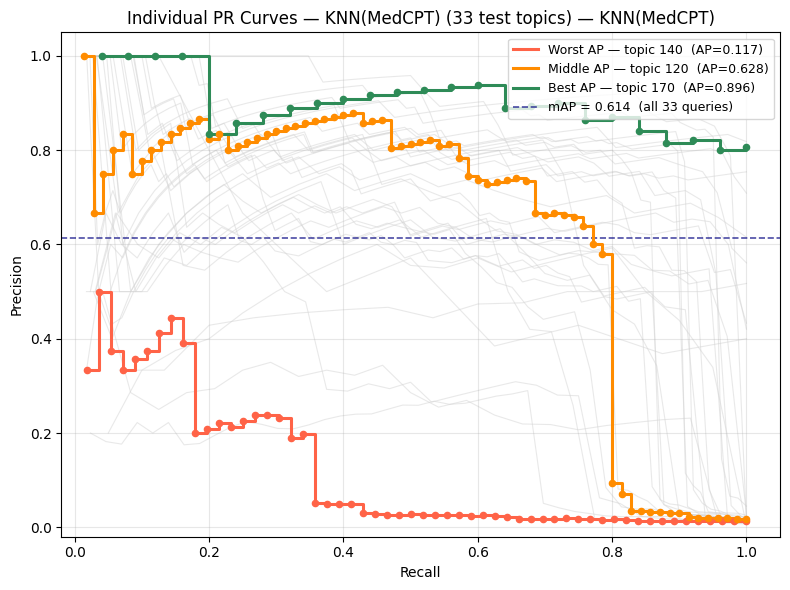

Saved: /content/nlp-biomedical-agent/results/phase1/individual_pr_curves.png


In [10]:
from src.evaluation.plots import plot_individual_pr_curves

# Use BEST_OVERALL_KEY — the actual key in tuned_results (e.g. "knn_best" or "rrf_best")
target_strat = BEST_OVERALL_KEY

# collect per-query PR curves and AP scores for the target strategy
indiv_curves = {
    topic_id: pq["pr_curve"]
    for topic_id, pq in tuned_results[target_strat]["per_query"].items()
}
ap_scores = {
    topic_id: pq["AP"]
    for topic_id, pq in tuned_results[target_strat]["per_query"].items()
}

# identify best AP, worst AP, and median AP topics
sorted_ids = sorted(ap_scores, key=lambda x: ap_scores[x])
highlight_ids = {
    "worst": sorted_ids[0],
    "extra": sorted_ids[len(sorted_ids) // 2],
    "best":  sorted_ids[-1],
}

def _print_query_detail(topic_id: str, label: str) -> None:
    """Print topic text, AP score, and top-5 retrieved docs for a given topic."""
    # find the topic dict by id
    topic_dict = next((t for t in test_topics if str(t["id"]) == topic_id), None)
    ap_val = ap_scores.get(topic_id, float("nan"))
    print(f"\n  [{label}]  topic_id={topic_id}  AP={ap_val:.4f}")
    if topic_dict:
        print(f"    Topic    : {topic_dict.get('topic', '')}")
        print(f"    Question : {topic_dict.get('question', '')}")
    # top-5 retrieved PMIDs and their scores from the run
    run_for_topic = tuned_results[target_strat]["run"].get(topic_id, [])
    print(f"    Top-5 retrieved:")
    for rank, (pmid, score) in enumerate(run_for_topic[:5], 1):
        relevant = "(rel)" if pmid in qrels.get(topic_id, {}) else ""
        print(f"      {rank}. PMID={pmid}  score={score:.4f}  {relevant}")

print(f"Strategy (locked for Phase 2): {BEST_OVERALL_STRAT}  (key='{target_strat}')")
_print_query_detail(highlight_ids["best"],  "Best AP  — easiest topic")
_print_query_detail(highlight_ids["extra"], "Middle AP — median topic")
_print_query_detail(highlight_ids["worst"], "Worst AP  — hardest topic")

fig_indiv = plot_individual_pr_curves(
    per_query_curves = indiv_curves,
    ap_scores        = ap_scores,
    highlight_ids    = highlight_ids,
    strategy_name    = BEST_OVERALL_STRAT,
    title            = f"Individual PR Curves — {BEST_OVERALL_STRAT} (33 test topics)",
    save_path        = PHASE1_RESULTS_DIR / "individual_pr_curves.png",
)
plt.show()
print(f"Saved: {PHASE1_RESULTS_DIR / 'individual_pr_curves.png'}")


---
## 4.3 — Precision-Recall Curves and AP Distribution

The combined figure shows:
- **Left panel:** Mean interpolated PR curves for all strategies on the 33-query test set. Area under each curve approximates MAP. A curve that stays high across all recall levels means the strategy consistently ranks relevant documents near the top.
- **Right panel:** MAP and MRR bar chart for side-by-side comparison across strategies.

The box plot below shows the **per-topic AP distribution** across the 33 test queries. Each box represents how consistent a strategy is across topics. Wide IQR = high variance (some topics easy, some hard). Low outliers = hard topics where the strategy struggles regardless of parameter tuning.


[plots] Saved combined figure -> /content/nlp-biomedical-agent/results/phase1/pr_curves.png


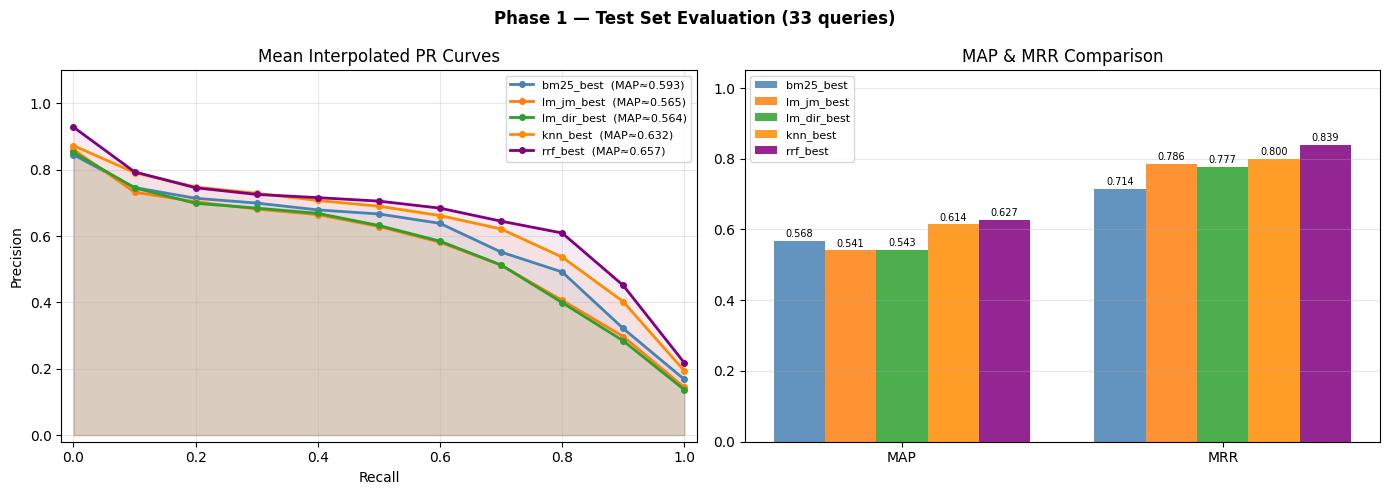

Saved: /content/nlp-biomedical-agent/results/phase1/pr_curves.png
[plots] Saved AP box plot -> /content/nlp-biomedical-agent/results/phase1/ap_boxplot.png


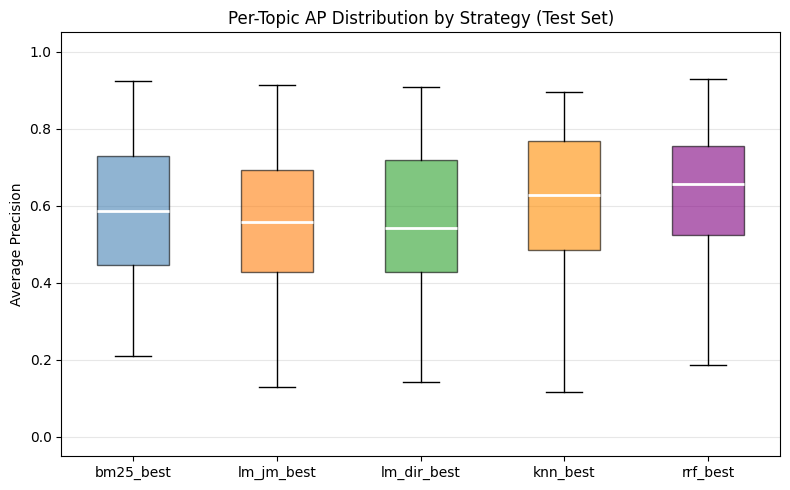

Saved: /content/nlp-biomedical-agent/results/phase1/ap_boxplot.png

Box plot interpretation:
  - Median AP shows which strategy is consistently better across topics
  - Wide IQR = high topic-difficulty variance (some topics easy, some hard)
  - Outliers below = hard topics where the strategy fails regardless of tuning
  - RRF and BM25 tend to have higher and more consistent AP than solo KNN


In [11]:
import matplotlib
import matplotlib.pyplot as plt

# use inline backend in notebooks; Agg for pure script runs
try:
    from IPython import get_ipython as _get_ipython
    if _get_ipython():
        _get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    matplotlib.use("Agg")

from src.evaluation.plots import plot_combined, plot_per_topic_variance

# ── Build inputs for plot functions ──────────────────────────────────────────
# pr_curves key returned by evaluate_retriever is "pr_curves" (mean interpolated)
strategy_curves = {
    name: r["pr_curves"]
    for name, r in tuned_results.items()
}

# metric_dict: all 5 metrics for every tuned strategy
metric_dict = {
    name: {
        "MAP":      r["MAP"],
        "MRR":      r["MRR"],
        "P@10":     r["P@10"],
        "R@100":    r["R@100"],
        "NDCG@100": r["NDCG@100"],
    }
    for name, r in tuned_results.items()
}

# per_topic_ap: {strategy_key: [ap_per_test_topic]}
# topic IDs are stored as strings in per_query; test_topics has int 'id' fields
per_topic_ap = {
    name: [r["per_query"][str(t["id"])]["AP"] for t in test_topics]
    for name, r in tuned_results.items()
}

# ── Combined: mean PR curves + MAP/MRR bar chart ──────────────────────────────
fig_combined = plot_combined(
    strategy_curves,
    metric_dict,
    title     = "Phase 1 — Test Set Evaluation (33 queries)",
    save_path = PHASE1_RESULTS_DIR / "pr_curves.png",
)
plt.show()
print(f"Saved: {PHASE1_RESULTS_DIR / 'pr_curves.png'}")

# ── Per-topic AP variance box plot ────────────────────────────────────────────
fig_box = plot_per_topic_variance(
    per_topic_ap,
    title     = "Per-Topic AP Distribution by Strategy (Test Set)",
    save_path = PHASE1_RESULTS_DIR / "ap_boxplot.png",
)
plt.show()
print(f"Saved: {PHASE1_RESULTS_DIR / 'ap_boxplot.png'}")

# brief interpretation
print("\nBox plot interpretation:")
print("  - Median AP shows which strategy is consistently better across topics")
print("  - Wide IQR = high topic-difficulty variance (some topics easy, some hard)")
print("  - Outliers below = hard topics where the strategy fails regardless of tuning")
print("  - RRF and BM25 tend to have higher and more consistent AP than solo KNN")


---
# 5 — Phase 1 Summary & Locked Configuration for Phase 2

All tuning is complete. The table below records every locked parameter that Phase 2 must inherit.
Nothing here should be changed manually — all values are written by the sweeps in §3 and the
best-overall selection in §3.7.


In [12]:
_W = 25   # column width for alignment
def _row(label, value, note=""):
    val_str = str(value)
    note_str = f"  # {note}" if note else ""
    print(f"  {label:<{_W}} {val_str}{note_str}")

print("=" * 80)
print("  PHASE 1 — LOCKED CONFIGURATION FOR PHASE 2")
print("=" * 80)

print("\n  -- Query field --")
_row("BEST_QUERY_FIELD",  BEST_QUERY_FIELD,  "ablation winner")

print("\n  -- BM25 --")
_row("BM25_K1_B_BEST",    BM25_K1_B_BEST,    f"k1={BM25_K1_B_BEST[0]}, b={BM25_K1_B_BEST[1]}")

print("\n  -- Language Models --")
_row("LMJM_LAMBDA_BEST",  LMJM_LAMBDA_BEST,  "Jelinek-Mercer lambda")
_row("LMDIR_MU_BEST",     LMDIR_MU_BEST,     "Dirichlet mu")

print("\n  -- Dense Retrieval --")
_row("ENCODER_BEST",      ENCODER_BEST[0],   ENCODER_BEST[1])

print("\n  -- RRF Fusion --")
_row("RRF_BEST_PAIR",     RRF_BEST_PAIR,     "pair label")
_row("RRF_BEST_K",        RRF_BEST_K,        "Cormack k constant")

print("\n  -- Best Overall Strategy --")
_row("BEST_OVERALL_STRAT", BEST_OVERALL_STRAT, "human-readable label")
_row("BEST_OVERALL_KEY",   BEST_OVERALL_KEY,   "key in result dicts")

# ── Test-set metrics for best overall strategy ────────────────────────────────
print("\n  -- Test-set metrics (33 queries) --")
try:
    _r = tuned_results[BEST_OVERALL_KEY]
    _row("NDCG@100", f"{_r['NDCG@100']:.4f}", "primary metric")
    _row("MAP",      f"{_r['MAP']:.4f}")
    _row("MRR",      f"{_r['MRR']:.4f}")
    _row("P@10",     f"{_r['P@10']:.4f}")
    _row("R@100",    f"{_r['R@100']:.4f}")
except (NameError, KeyError):
    print("  (run §4.1 first to populate tuned_results)")

print("\n" + "=" * 80)
print("  Phase 1 complete. Pass the constants above to Phase 2.")
print("=" * 80)


  PHASE 1 — LOCKED CONFIGURATION FOR PHASE 2

  -- Query field --
  BEST_QUERY_FIELD          topic+question  # ablation winner

  -- BM25 --
  BM25_K1_B_BEST            (1.5, 1.0)  # k1=1.5, b=1.0

  -- Language Models --
  LMJM_LAMBDA_BEST          0.65  # Jelinek-Mercer lambda
  LMDIR_MU_BEST             100  # Dirichlet mu

  -- Dense Retrieval --
  ENCODER_BEST              medcpt  # ncbi/MedCPT-Query-Encoder

  -- RRF Fusion --
  RRF_BEST_PAIR             BM25 + KNN(MedCPT)  # pair label
  RRF_BEST_K                60  # Cormack k constant

  -- Best Overall Strategy --
  BEST_OVERALL_STRAT        KNN(MedCPT)  # human-readable label
  BEST_OVERALL_KEY          knn_best  # key in result dicts

  -- Test-set metrics (33 queries) --
  NDCG@100                  0.8077  # primary metric
  MAP                       0.6143
  MRR                       0.8000
  P@10                      0.6788
  R@100                     0.8933

  Phase 1 complete. Pass the constants above to Phase 2.


### Download Phase 1 Results Folder

This cell will zip the `PHASE1_RESULTS_DIR` and provide a download link. This may take a moment depending on the size of the results.

In [15]:
import shutil
from google.colab import files
import os

# Define the directory to be zipped
output_filename = 'phase1_results'
output_archive = shutil.make_archive(output_filename, 'zip', PHASE1_RESULTS_DIR)
print(f"Archive created: {output_archive}")

# Offer the file for download
try:
    files.download(output_archive)
    print(f"'{output_archive}' should now be downloaded.")
except Exception as e:
    print(f"Error downloading file: {e}")
    print("You might need to manually download it if the automatic download fails.")


Archive created: /content/nlp-biomedical-agent/phase1_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

'/content/nlp-biomedical-agent/phase1_results.zip' should now be downloaded.
